In [1]:
# 1st: clean_spark
# 2nd: if doesn't work, clean_spark + restart kernel
# 3rd: if doesn't work, podman-compose down

In [2]:
# censys_pdf = censys_df.pandas_api()  # OK, SUBSET OF PANDAS API
# censys_df.toPandas()  # BE CAREFUL, THIS MAY CRASH YOUR ENVIRONMENT (needs podman-compose down)

In [12]:
# this creates your spark instance; if you clean_spark, you need to run this again
# you likely don't need to change the configurations inside this file
%run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/remi.hendriks@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [4]:
# RUN THIS BEFORE RESTARTING THE PYTHON KERNEL
# RUN THIS IF YOU WANT TO RESTART YOUR SPARK INSTANCE
# run podman-compose down if you mess up this and you need to restart your jupyter
clean_spark()

CLEANING SPARK INSTANCE...


In [5]:
# INSTALL ANY PYTHON PACKAGE YOU NEED HERE!!
# restart the kernel after installing new pkgs
#!pip install <pkg_name>

In [29]:
# system imports
import os
from datetime import datetime

# installed pkg imports
import numpy as np
import pandas as pd
import ipaddress
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# spark imports
import pyspark.sql.functions as psf
import pyspark.sql.types as pst
from pyspark.storagelevel import StorageLevel
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, LongType, BooleanType, ArrayType, DoubleType


# download anycast census
import requests # query github
import gzip # read .json.gz files

# local python files imports

In [14]:
# About Censys data: https://search.censys.io/
# https://search.censys.io/search/definitions?resource=hosts

# you have access to the following dates:
#year=2023/month=08/day=22
#year=2023/month=09/day=19
#year=2023/month=10/day=24
#year=2023/month=11/day=21
#year=2023/month=12/day=19
#year=2024/month=01/day=16
#year=2024/month=02/day=20
#year=2024/month=03/day=12

#year=2024/month=09/day=10 is the latest matching

ts = datetime(2024, 9, 10)  # year=2024/month=01/day=16
CENSYS_BASE_PATH_FMT = "s3a://censys/dataset=universal-internet-dataset-v2-ipv4/format=parquet/"
CENSYS_PATH_FMT = os.path.join(CENSYS_BASE_PATH_FMT, "year={year}/month={month:02d}/day={day:02d}")

#IP2location dataset TODO upload
LOCATION_BASE_PATH = "../dataset/warehouse/"
LOCATION_FILE_NAME = "20240909_netstats_ip2location.csv"

In [15]:
censys_path = CENSYS_PATH_FMT.format(year=ts.year, month=ts.month, day=ts.day)
censys_df = spark.read.option("basePath", CENSYS_BASE_PATH_FMT).parquet(censys_path)

In [16]:
def download_date(year, month, day, version) -> pd.DataFrame:
    """Download and return census data for a specific date as a DataFrame.

    Args:
        year (int): The year of the data to download.
        month (int): The month of the data to download.
        day (int): The day of the data to download.
        version (str): The version of the census data ('v4' or 'v6').

    Returns:
        pd.DataFrame: DataFrame containing the census data for the specified date.
    """
    # Return error if date is before census start (2024/03/20)
    if (year, month, day) < (2024, 3, 20):
        raise ValueError("Date is before census start date of 2024-03-20")

    # Return error if date is in the future
    if datetime(year, month, day) > datetime.now():
        raise ValueError("Date is in the future")

    # URL e.g., https://github.com/ut-dacs/anycast-census/blob/main/2025/10/31/IPv4.parquet
    date_str = f"{year:04d}/{month:02d}/{day:02d}"
    url = f"https://github.com/ut-dacs/anycast-census/blob/main/{date_str}/IP{version}.parquet?raw=true"

    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Failed to download {url}: HTTP {response.status_code}")

    # Get the URL content as a bytes object
    data_bytes = response.content
    # Read the Parquet data into a DataFrame
    df = pd.read_parquet(pd.io.common.BytesIO(data_bytes))
    return df

In [17]:
ip_location = os.path.join(LOCATION_BASE_PATH, LOCATION_FILE_NAME)
ip_location_df = spark.read.option("header", True).csv(ip_location)
#ip_location_df.show(5, truncate = False)

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/home/sparky/data/dataset/warehouse/20240909_netstats_ip2location.csv.

In [18]:
%%time
censys_df.filter(
    psf.array_contains(psf.col("services.service_name"), "LDAP")
).select(psf.explode_outer(psf.arrays_zip(
    censys_df.services.service_name.alias("service_name"), 
    censys_df.services.port.alias("port")))
).select("col.service_name", "col.port"
).filter(psf.col("service_name") == "LDAP"
).groupBy("port").count().sort("count", ascending=False).show()

+-----+-----+
| port|count|
+-----+-----+
|  389|86050|
|  636|37760|
| 8389|  174|
| 8636|   70|
| 3489|   13|
|30636|    1|
| 3636|    1|
|  700|    1|
+-----+-----+

CPU times: user 42.1 ms, sys: 16.5 ms, total: 58.5 ms
Wall time: 4min 35s


In [111]:
censys_df.select(psf.explode("services").alias("svc")) \
         .groupBy("svc.transport") \
         .count() \
         .orderBy("count", ascending=False) \
         .show(truncate=False)

+---------+---------+
|transport|count    |
+---------+---------+
|TCP      |754668385|
|UDP      |76684051 |
|QUIC     |354289   |
+---------+---------+



In [19]:
censys_df.printSchema()

root
 |-- host_identifier: struct (nullable = true)
 |    |-- ipv4: string (nullable = true)
 |    |-- ipv6: string (nullable = true)
 |    |-- name: string (nullable = true)
 |-- services: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- port: long (nullable = true)
 |    |    |-- transport: string (nullable = true)
 |    |    |-- service_name: string (nullable = true)
 |    |    |-- perspective: string (nullable = true)
 |    |    |-- observed_at: timestamp (nullable = true)
 |    |    |-- tls: struct (nullable = true)
 |    |    |    |-- version_selected: string (nullable = true)
 |    |    |    |-- cipher_selected: string (nullable = true)
 |    |    |    |-- certificates: struct (nullable = true)
 |    |    |    |    |-- leaf_fp_sha_256: binary (nullable = true)
 |    |    |    |    |-- chain_fps_sha_256: array (nullable = true)
 |    |    |    |    |    |-- element: binary (containsNull = true)
 |    |    |    |    |-- leaf_data: struct (null

In [20]:
censys_df.select("services.transport").show(10, truncate = False) # check if it contains quick

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|transport                                                                                                                                                                                                                                                                          |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[TCP, TCP]                                                                                                                                                           

In [37]:
# define LACeS struct

# locations of anycast sites
location_struct = StructType([
    StructField("city", StringType(), True),
    StructField("code_country", StringType(), True), 
    StructField("id", StringType(), True),
    StructField("latitude", DoubleType(), True), 
    StructField("longitude", DoubleType(), True)
])

# schema
full_schema = StructType([
    StructField("prefix", StringType(), True),
    StructField("AB_ICMPv4", LongType(), True),
    StructField("AB_TCPv4", LongType(), True),
    StructField("AB_DNSv4", LongType(), True),
    StructField("GCD_ICMPv4", LongType(), True),
    StructField("GCD_TCPv4", LongType(), True),
    StructField("partial", BooleanType(), True),
    StructField("backing_prefix", StringType(), True),
    StructField("ASN", StringType(), True),
    # list of location structs
    StructField("locations", ArrayType(location_struct), True) 
])


In [38]:
# load in anycast data

anycast_df = download_date(ts.year, ts.month, ts.day, "v4")
anycast_df = anycast_df[anycast_df['GCD_ICMPv4'] > 1] # filter on GCD-confirmed (high accuracy)

anycast_df.head()

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations
0,1.0.0.0/24,25,26,1,59,25,False,1.0.0.0/24,13335,"[{'city': 'Johannesburg', 'code_country': 'ZA'..."
1,1.1.1.0/24,25,25,26,59,21,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'code_country': 'IN', '..."
2,1.10.10.0/24,2,0,2,3,0,False,1.10.10.0/24,148000,"[{'city': 'Mumbai', 'code_country': 'IN', 'id'..."
3,1.12.0.0/24,3,0,3,4,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Frankfurt-am-Main', 'code_country':..."
4,1.12.12.0/24,3,1,0,4,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'code_country': 'HK', '..."


In [40]:
anycast_spark = spark.createDataFrame(anycast_df, schema=full_schema)

anycast_spark.printSchema()
anycast_spark.show(1, truncate=False)

root
 |-- prefix: string (nullable = true)
 |-- AB_ICMPv4: long (nullable = true)
 |-- AB_TCPv4: long (nullable = true)
 |-- AB_DNSv4: long (nullable = true)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- GCD_TCPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- backing_prefix: string (nullable = true)
 |-- ASN: string (nullable = true)
 |-- locations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- code_country: string (nullable = true)
 |    |    |-- id: string (nullable = true)
 |    |    |-- latitude: double (nullable = true)
 |    |    |-- longitude: double (nullable = true)

+----------+---------+--------+--------+----------+---------+-------+--------------+-----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [41]:
# get unique anycast prefixes
anycast_prefixes = anycast_spark.select("prefix").distinct().collect()

# Show first 5 prefixes
print([row["prefix"] for row in anycast_prefixes[:5]])


['104.25.84.0/24', '104.25.95.0/24', '104.27.122.0/24', '104.27.200.0/24', '104.27.47.0/24']


In [43]:
# add /24 prefix column to censys data

censys_with_prefix = censys_df.withColumn(
    "prefix",
    psf.concat_ws(
        ".",
        psf.split("host_identifier.ipv4", "\\.")[0],
        psf.split("host_identifier.ipv4", "\\.")[1],
        psf.split("host_identifier.ipv4", "\\.")[2]
    )
).withColumn(
    "prefix", psf.concat_ws("", "prefix", psf.lit(".0/24"))
)

In [50]:
# join censys and anycast datasets
censys_anycast = censys_with_prefix.join(
    anycast_spark,
    on="prefix",
    how="inner"
).select( # TODO add all required columns here
    "prefix",
    "GCD_ICMPv4",
    "partial",
    "backing_prefix",
    "host_identifier",
    "services.port",
    "services.transport",
    "services.service_name",
    "services.http.response.headers",
    "ASN",
    "locations",
    "autonomous_system", # contains more than just ASN
).persist(StorageLevel.MEMORY_AND_DISK)

In [48]:
# for how many anycast prefixes does censys have data

print(f"Number of anycast prefixes: {anycast_spark.select('prefix').distinct().count():,}")
print(f"Number of anycast prefixes with censys data: {censys_anycast.select('prefix').distinct().count():,}")

Number of anycast prefixes: 12180
Number of anycast prefixes with censys data: 11720


In [ ]:
# show first row
censys_anycast.show(1, truncate=False)

In [51]:
censys_anycast.printSchema()

root
 |-- prefix: string (nullable = false)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- backing_prefix: string (nullable = true)
 |-- host_identifier: struct (nullable = true)
 |    |-- ipv4: string (nullable = true)
 |    |-- ipv6: string (nullable = true)
 |    |-- name: string (nullable = true)
 |-- port: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- transport: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- service_name: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- headers: array (nullable = true)
 |    |-- element: array (containsNull = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- key: string (nullable = true)
 |    |    |    |-- value: struct (nullable = true)
 |    |    |    |    |-- headers: array (nullable = true)
 |    |    |    |    |    |-- element: binary (containsNull = true)
 |-- ASN: string (nullable = true)

# General Data

In [ ]:
print(f"Original Censys IPs: {censys_df.select('host_identifier.ipv4').distinct().count():,}")

In [ ]:
print(f"Total Censys IPs in Anycast subnets: {censys_anycast.select('host_identifier.ipv4').distinct().count():,}") # martin -> 2,180,518

In [13]:
unmatched_prefixes = anycast_spark.select("prefix").distinct().join(
    censys_with_prefix.select("prefix").distinct(),
    on="prefix",
    how="left_anti"
)
total = anycast_spark.select("prefix").distinct().count() # Total number of Anycast /24 prefixes
unmatched = unmatched_prefixes.count() # Anycast /24 prefixes that weren't found in the Censys data
print("Total anycast /24 prefixes: ", total)
print("Total unmatched prefixes: ", unmatched)
print("Total matched prefixes: ", total - unmatched)

print(f"Matched prefixes: {(100 * (total - unmatched) / total):.2f}%")

Total anycast /24 prefixes:  12186
Total unmatched prefixes:  466
Total matched prefixes:  11720
Matched prefixes: 96.18%


In [24]:
matched = total - unmatched
print(f"Average IPs per /24 prefix: {(total_censys_anycast/matched):.2f}")

Average IPs per /24 prefix: 186.05


In [16]:
top_asns = censys_anycast \
    .groupBy(
        "autonomous_system.asn",
        "autonomous_system.name",
        "autonomous_system.organization"
    ) \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10)

top_asns.show(truncate=False)

+------+-----------------------------------+------------+------+
|asn   |name                               |organization|count |
+------+-----------------------------------+------------+------+
|396982|GOOGLE-CLOUD-PLATFORM              |NULL        |826588|
|13335 |CLOUDFLARENET                      |NULL        |746556|
|54113 |FASTLY                             |NULL        |115122|
|16509 |AMAZON-02                          |NULL        |112578|
|209242|CLOUDFLARESPECTRUM Cloudflare, Inc.|NULL        |66527 |
|15169 |GOOGLE                             |NULL        |50877 |
|15967 |NETARTGROUP                        |NULL        |46904 |
|15133 |EDGECAST                           |NULL        |22785 |
|40509 |FLY                                |NULL        |19949 |
|207266|AFILIAS-SECONDARY-DNS              |NULL        |19308 |
+------+-----------------------------------+------------+------+



In [100]:
num_unique_asns = censys_anycast.select("autonomous_system.asn").distinct().count()
print(f"Number of unique ASNs using Anycast: {num_unique_asns}")

Number of unique ASNs using Anycast: 709


# Analyzing the services running on Anycast

In [18]:
# Check what services are in a specific IP
censys_anycast.filter(
    censys_anycast["host_identifier.ipv4"] == "104.20.172.83"
).select("service_name").show(truncate=False)

+------------------------------------------------------------------------------+
|service_name                                                                  |
+------------------------------------------------------------------------------+
|[HTTP, HTTP, HTTP, HTTP, HTTP, HTTP, HTTP, HTTP, HTTP, HTTP, HTTP, HTTP, HTTP]|
+------------------------------------------------------------------------------+



In [104]:
# Check if an IP is in the combined df
censys_anycast.filter(
    censys_anycast["host_identifier.ipv4"] == "43.132.147.88"
).count()

0

In [112]:
service_freq = censys_anycast.select(psf.explode("service_name").alias("service")
                                    ).filter("service != 'UNKNOWN'").groupBy("service").count().orderBy("count", ascending=False)

service_freq.show(100,truncate=False)

+-------------------+--------+
|service            |count   |
+-------------------+--------+
|HTTP               |12893073|
|SMTP               |138929  |
|DNS                |90984   |
|IMAP               |88850   |
|POP3               |88301   |
|MYSQL              |62290   |
|FTP                |44718   |
|SVR                |34196   |
|POSTGRES           |31111   |
|SSH                |24950   |
|IKE                |4111    |
|SNMP               |1853    |
|NTP                |1754    |
|MINECRAFT          |1713    |
|HIKVISION          |1550    |
|TELNET             |1385    |
|MDNS               |1195    |
|EPMD               |1157    |
|SIP                |1116    |
|PORTMAP            |782     |
|CISCO_IPSLA        |762     |
|MURMUR             |729     |
|L2TP               |721     |
|KUBERNETES         |690     |
|COAP               |687     |
|MQTT               |618     |
|RDP                |480     |
|ZEROMQ             |374     |
|REDIS              |345     |
|CWMP   

In [49]:
print(f"Total distinct services (excluding UNKNOWN): {service_freq.count()}")

Total distinct services (excluding UNKNOWN): 96


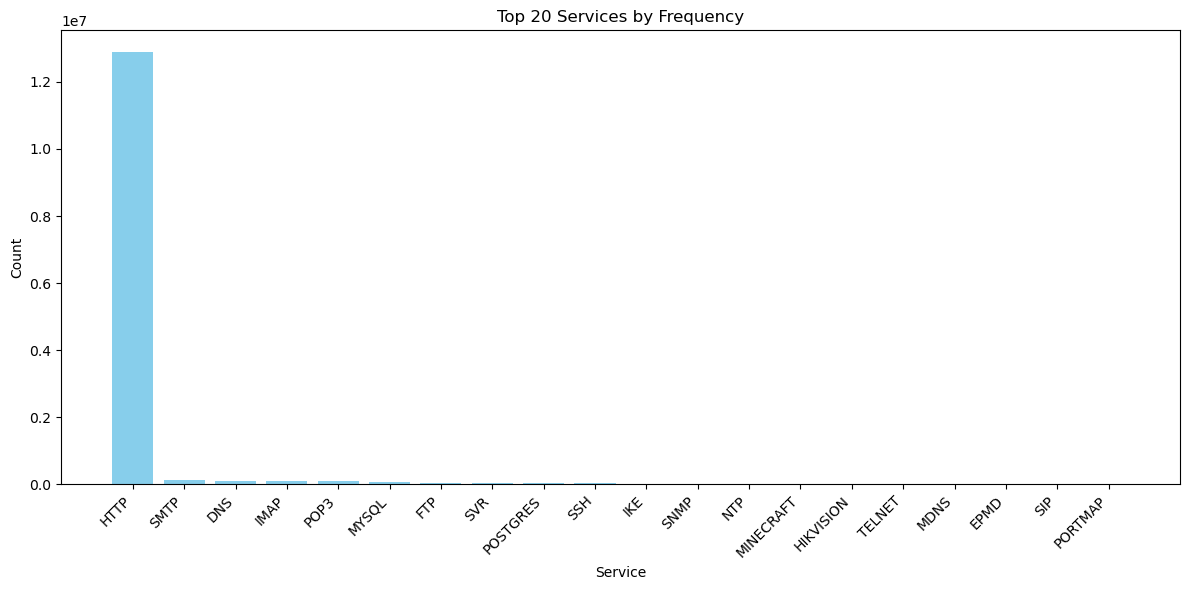

In [113]:
# Plotting a histogram by converting to pandas, top 20 services only
# This does not filter unique services per IP address
service_freq_pd = service_freq.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_freq_pd["service"], service_freq_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Services by Frequency")
plt.tight_layout()
plt.show()

### Above graph is highly skewed by CDNs deploying many http services per IP address

In [21]:
# We want unique services per IP, so for example multiple HTTP are counted as 1 
service_freq_unique = censys_anycast \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_freq_unique.show(10, truncate=False)

+--------+-------+
|service |count  |
+--------+-------+
|HTTP    |2087197|
|DNS     |90976  |
|SMTP    |46985  |
|FTP     |44692  |
|IMAP    |44455  |
|POP3    |44435  |
|MYSQL   |31364  |
|POSTGRES|31111  |
|SSH     |23770  |
|IKE     |4111   |
+--------+-------+
only showing top 10 rows



In [22]:
total_services = service_freq_unique.agg(psf.sum("count").alias("total")).collect()[0]["total"]

# Add a percentage column
service_percent_df = service_freq_unique \
    .withColumn("percentage", (psf.col("count") / psf.lit(total_services)) * 100)

# Show results
service_percent_df.orderBy("percentage", ascending=False).show(20, truncate=False)

+-----------+-------+--------------------+
|service    |count  |percentage          |
+-----------+-------+--------------------+
|HTTP       |2087197|84.61117799911626   |
|DNS        |90976  |3.688001913402329   |
|SMTP       |46985  |1.904686619561296   |
|FTP        |44692  |1.811732561486292   |
|IMAP       |44455  |1.802125011654728   |
|POP3       |44435  |1.8013142479558621  |
|MYSQL      |31364  |1.2714396325618917  |
|POSTGRES   |31111  |1.261183471771235   |
|SSH        |23770  |0.9635926561024157  |
|IKE        |4111   |0.1666524783019365  |
|SNMP       |1853   |0.07511725669994851 |
|NTP        |1754   |0.07110397639056108 |
|MINECRAFT  |1713   |0.06944191080788548 |
|MDNS       |1195   |0.04844313100725228 |
|EPMD       |1157   |0.0469026799794066  |
|SIP        |878    |0.03559252638022385 |
|CISCO_IPSLA|762    |0.030890096926800198|
|TELNET     |754    |0.03056579144725374 |
|MURMUR     |729    |0.029552336823671057|
|L2TP       |721    |0.029228031344124602|
+----------

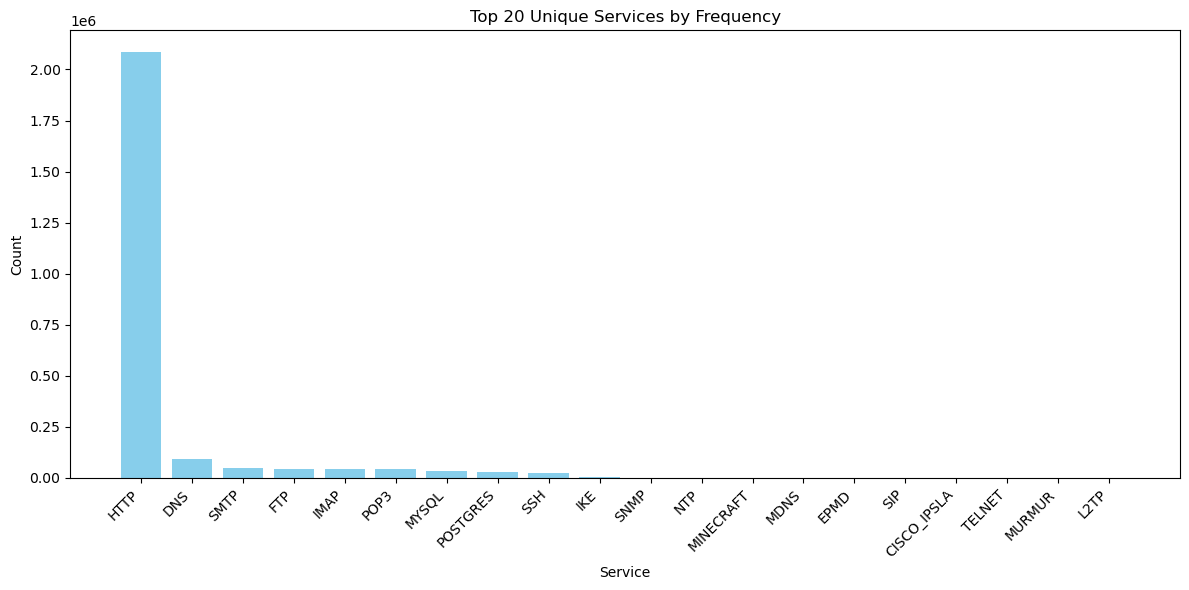

In [59]:
service_freq_unique_pd = service_freq_unique.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_freq_unique_pd["service"], service_freq_unique_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Services by Frequency")
plt.tight_layout()
plt.show()

### Above graph is not too useful for us as the http services deployed by big CDNs like Cloudflare are very overbearing

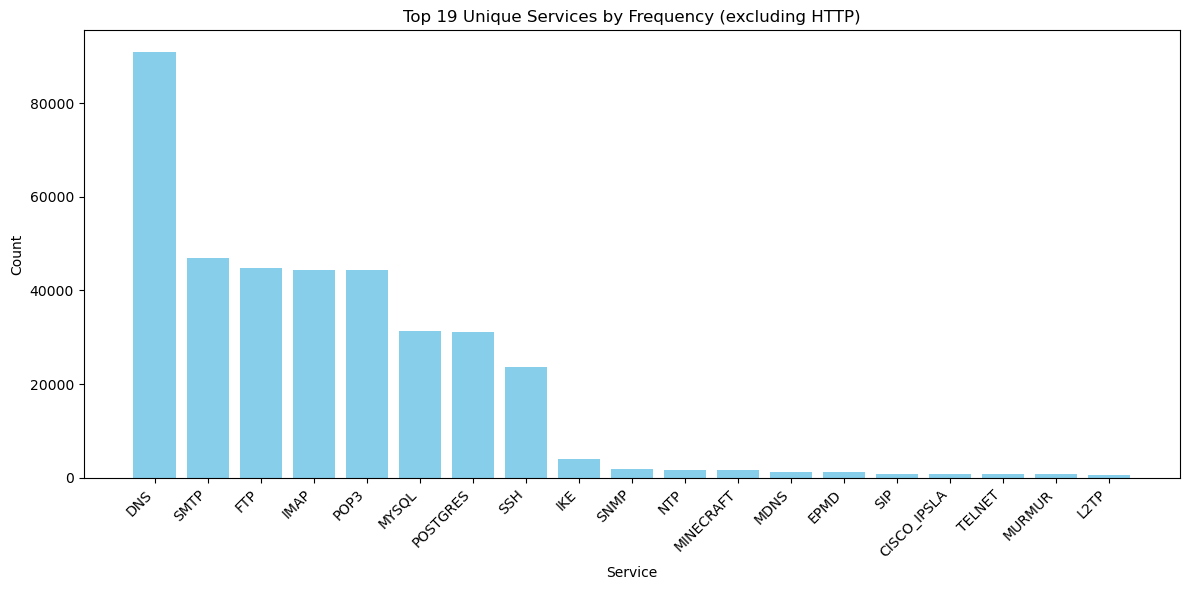

In [61]:
# Remove HTTP from the plot so the other services are more easily readable
filtered_services = service_freq_unique_pd[service_freq_unique_pd["service"] != "HTTP"]
plt.figure(figsize=(12, 6))
plt.bar(filtered_services["service"], filtered_services["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 19 Unique Services by Frequency (excluding HTTP)")
plt.tight_layout()
plt.show()

### Graph allows us to draw initial conclusions about how the services are distributed, however since we ignore HTTP it is not very accurate and we must instead look at hte picture without seeing the big CDNs to draw conclusions about service deployment.

In [21]:
censys_anycast \
    .filter(psf.col("autonomous_system.asn") == 13335) \
    .select(
        "autonomous_system.asn",
        "autonomous_system.name",
        "autonomous_system.organization"
    ) \
    .distinct() \
    .show(truncate=False)


+-----+-------------+------------+
|asn  |name         |organization|
+-----+-------------+------------+
|13335|CLOUDFLARENET|NULL        |
+-----+-------------+------------+



In [14]:
# Asn 13335 corresponds to Cloudflare
service_cloudflare = censys_anycast \
    .filter(psf.col("autonomous_system.asn") == 13335) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

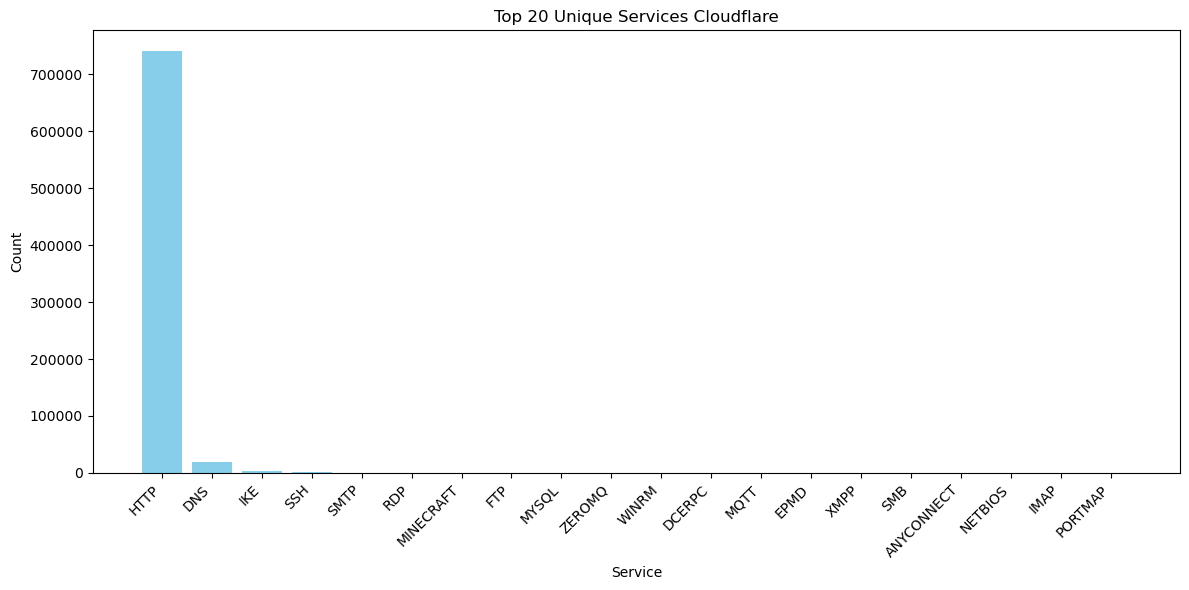

In [15]:
service_cloudflare_pd = service_cloudflare.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_cloudflare_pd["service"], service_cloudflare_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Services Cloudflare")
plt.tight_layout()
plt.show()

In [67]:
service_google = censys_anycast \
    .filter(psf.col("autonomous_system.asn") == 396982) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

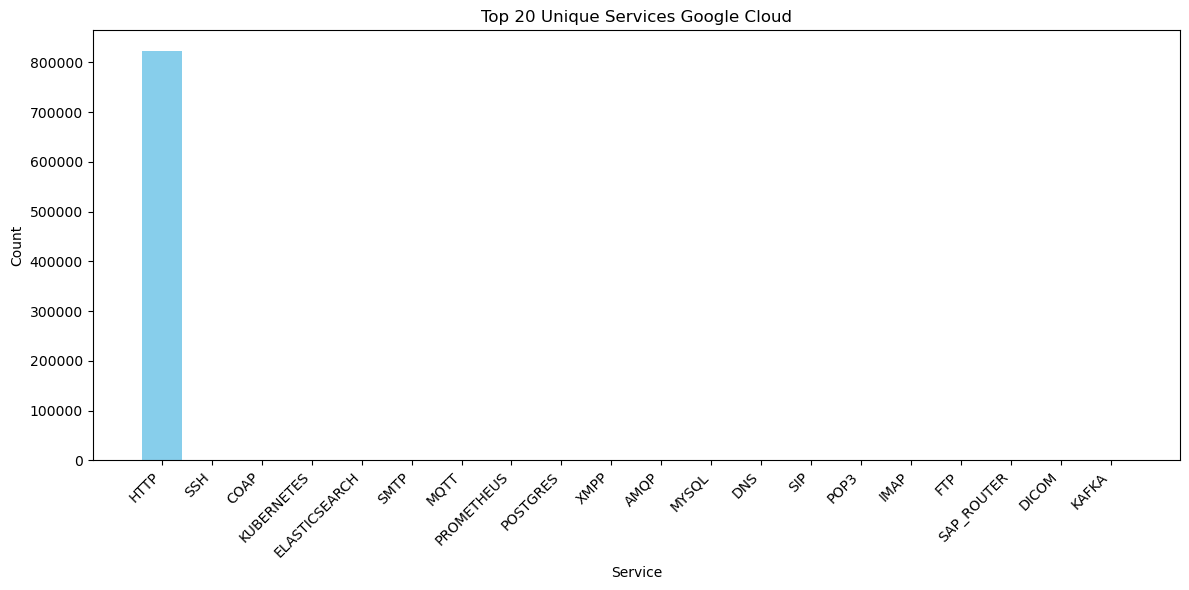

In [68]:
service_google_pd = service_google.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_google_pd["service"], service_google_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Services Google Cloud")
plt.tight_layout()
plt.show()

In [73]:
service_fastly = censys_anycast \
    .filter(psf.col("autonomous_system.asn") == 54113) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

In [38]:
service_fastly.show(truncate=False)

+-------+------+
|service|count |
+-------+------+
|HTTP   |114904|
|DNS    |8     |
+-------+------+



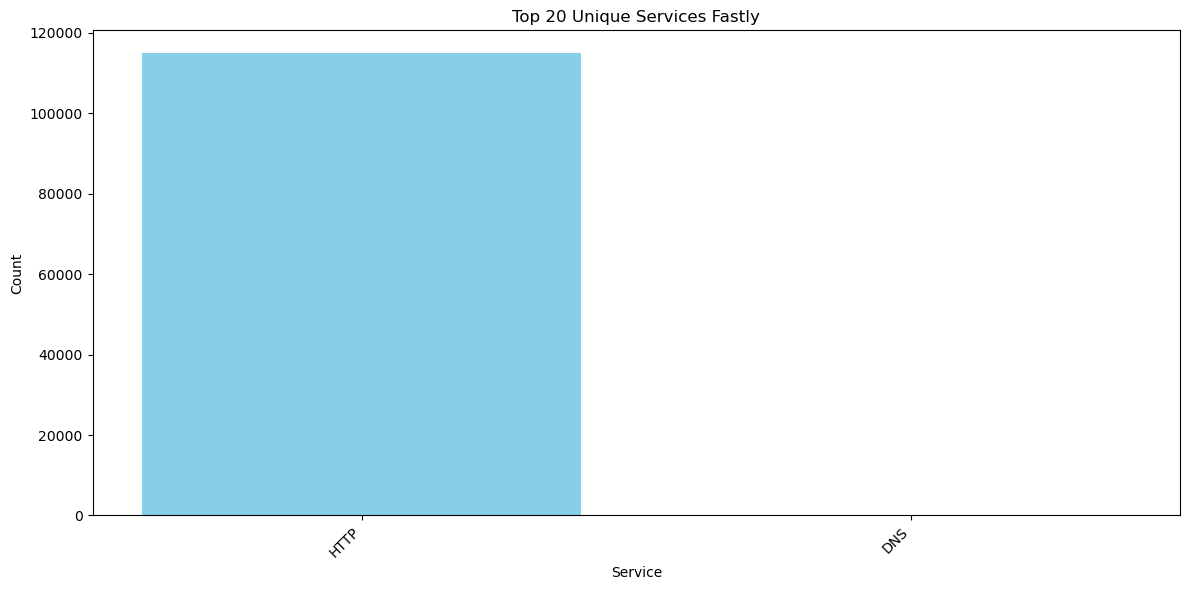

In [74]:
service_fastly_pd = service_fastly.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_fastly_pd["service"], service_fastly_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Services Fastly")
plt.tight_layout()
plt.show()

In [76]:
service_amazon = censys_anycast \
    .filter(psf.col("autonomous_system.asn") == 16509) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

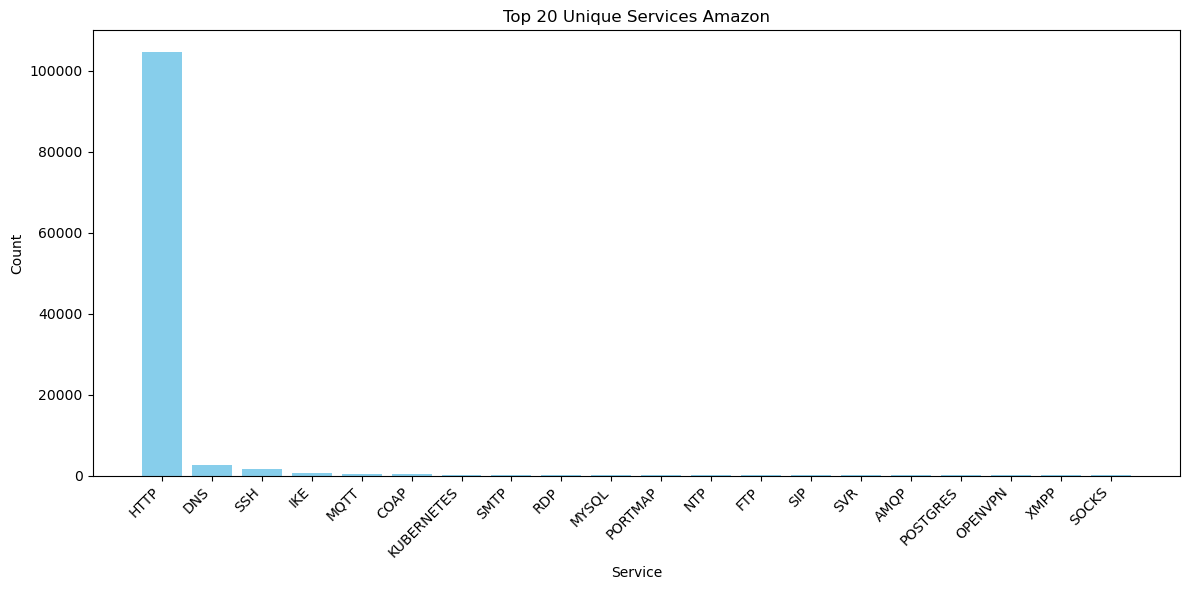

In [77]:
service_amazon_pd = service_amazon.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_amazon_pd["service"], service_amazon_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Services Amazon")
plt.tight_layout()
plt.show()

In [86]:
service_cloudflarespec = censys_anycast \
    .filter(psf.col("autonomous_system.asn") == 209242) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

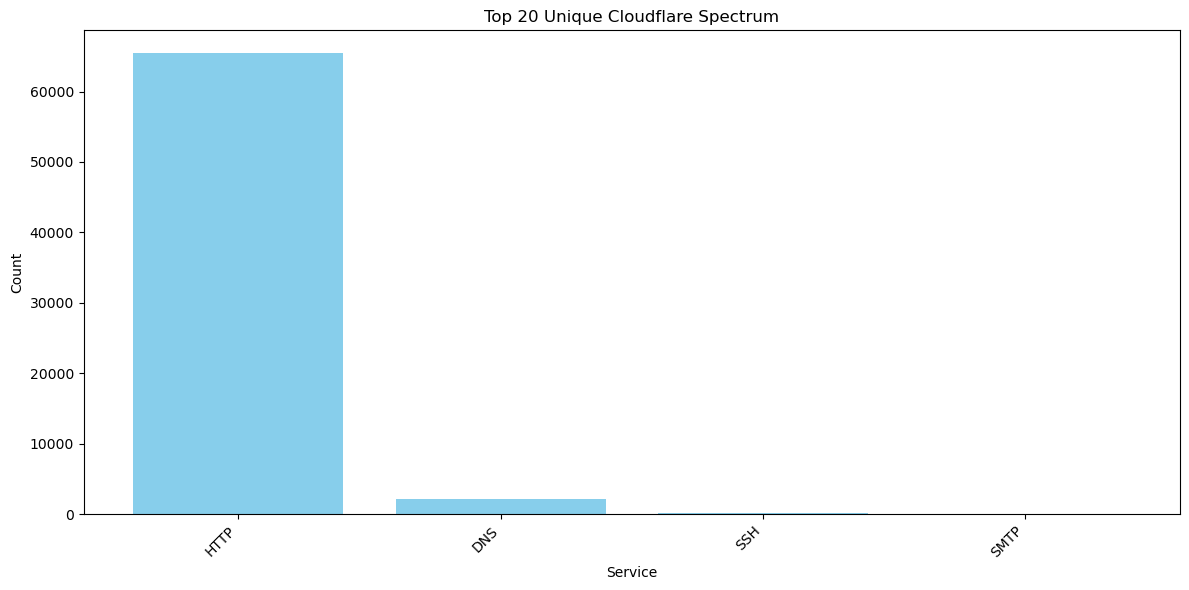

In [87]:
service_cloudflarespec_pd = service_cloudflarespec.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_cloudflarespec_pd["service"], service_cloudflarespec_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Cloudflare Spectrum")
plt.tight_layout()
plt.show()

In [94]:
excluded_asns = [396982, 13335, 54113, 16509, 209242]

service_other = censys_anycast \
    .filter(~psf.col("autonomous_system.asn").isin(excluded_asns)) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

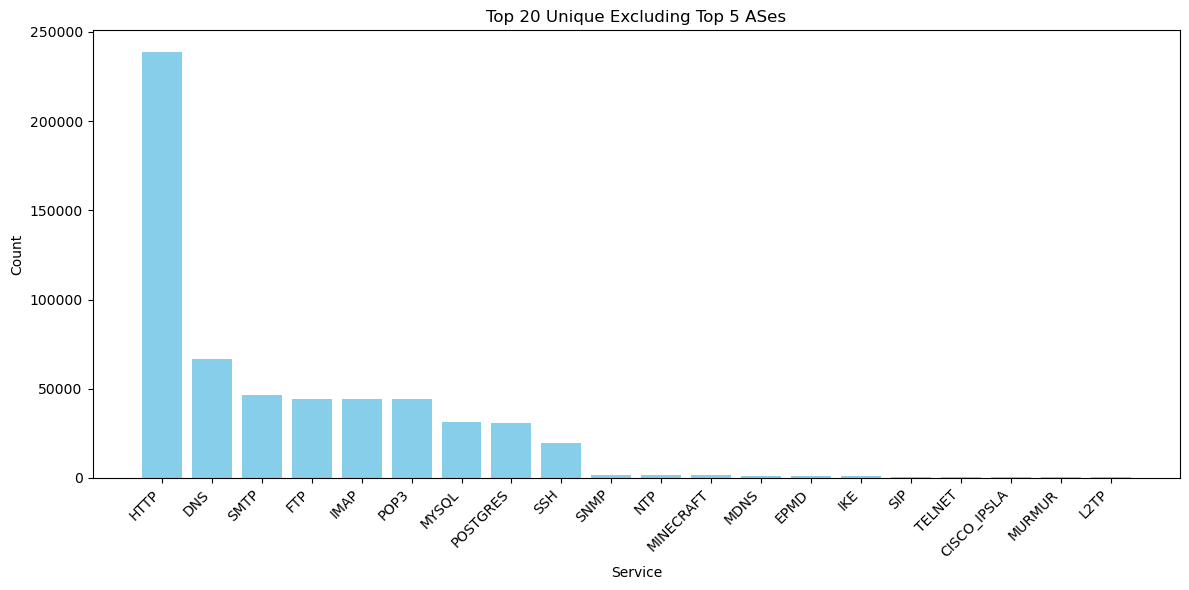

In [95]:
service_other_pd = service_other.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_other_pd["service"], service_other_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Excluding Top 5 ASes")
plt.tight_layout()
plt.show()

### Now that the top 5 CDNs are filtered out, the data is a lot more significant. HTTP still dominates over the other services, however we can see how the other services are distributed

In [68]:
# Define Top 5 ASNs
top5_asns = [396982, 13335, 54113, 16509, 209242]

# Step 1: Label entries as Top 5 vs Other, explode services
exploded_df = (
    censys_anycast
    .withColumn("group", psf.when(psf.col("autonomous_system.asn").isin(top5_asns), "Top 5 ASes").otherwise("Other ASes"))
    .withColumn("service", psf.explode("service_name"))
    .filter(psf.col("service") != "UNKNOWN")
    .select("group", "service", "host_identifier.ipv4")
)

# Step 2: Group by service and group, count unique IPs
service_grouped = (
    exploded_df
    .groupBy("service", "group")
    .agg(psf.countDistinct("ipv4").alias("ip_count"))
)

# Step 3: Get top 20 services by total IP count
top_services_df = (
    service_grouped
    .groupBy("service")
    .agg(psf.sum("ip_count").alias("total_ip_count"))
    .orderBy(psf.desc("total_ip_count"))
    .limit(20)
    .select("service")  # Just get the service names
)

# Step 4: Join back to filter original grouped data to top 20 only
top_services = service_grouped.join(top_services_df, on="service", how="inner")

# Step 5: Convert to Pandas for plotting
top_services_pd = top_services.toPandas()

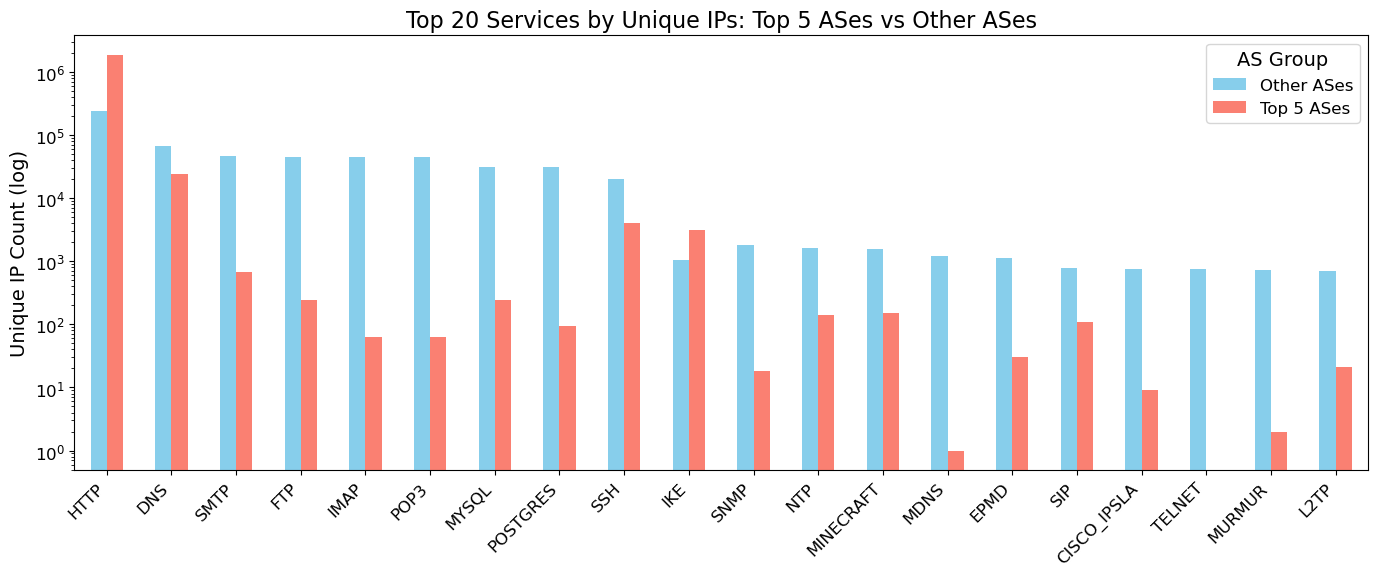

In [91]:
# Pivot the DataFrame: rows are services, columns are groups ("Top 5 ASes", "Other ASes")
pivot_df = top_services_pd.pivot(index="service", columns="group", values="ip_count").fillna(0)

# Sort by total IP count (Top 5 + Other)
pivot_df["Total"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by="Total", ascending=False).drop(columns="Total")

# Plot
ax = pivot_df.plot(kind="bar", figsize=(14, 6), color=["skyblue", "salmon"])
ax.set_yscale("log")
plt.title("Top 20 Services by Unique IPs: Top 5 ASes vs Other ASes")
plt.ylabel("Unique IP Count (log)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha='right')
plt.legend(title="AS Group")
plt.tight_layout()
plt.savefig("output/tp_service_comparison.pdf", bbox_inches='tight')
plt.show()

SSH is a misconfig  due to laziness. The services deployed for the unicast addresses are also accessible in the anycast addresses. Default kernel behaviour is the speculation.
Look into minecraft anycast
Telnet is old and not secure, top 5 likely already replaced it

In [73]:
pivot = top_services_pd.pivot(index='service', columns='group', values='ip_count')
print(pivot.head(20))

group        Other ASes  Top 5 ASes
service                            
CISCO_IPSLA       753.0         9.0
DNS             66911.0     24065.0
EPMD             1127.0        30.0
FTP             44451.0       241.0
HTTP           238963.0   1848234.0
IKE              1031.0      3080.0
IMAP            44391.0        64.0
L2TP              700.0        21.0
MDNS             1194.0         1.0
MINECRAFT        1562.0       151.0
MURMUR            727.0         2.0
MYSQL           31120.0       244.0
NTP              1613.0       141.0
POP3            44373.0        62.0
POSTGRES        31016.0        95.0
SIP               768.0       110.0
SMTP            46297.0       688.0
SNMP             1835.0        18.0
SSH             19804.0      3966.0
TELNET            754.0         NaN


# Analyzing the ports that services are deployed on

In [11]:
port_freq = censys_anycast.select(psf.explode("port").alias("ports")
                                    ).groupBy("ports").count().orderBy("count", ascending=False)

port_freq.show(10, truncate=False)

+-----+-------+
|ports|count  |
+-----+-------+
|443  |1742223|
|80   |1500880|
|8080 |818654 |
|8443 |809479 |
|2053 |803714 |
|2083 |803712 |
|8880 |803677 |
|2087 |803649 |
|2086 |803606 |
|2096 |803119 |
+-----+-------+
only showing top 10 rows



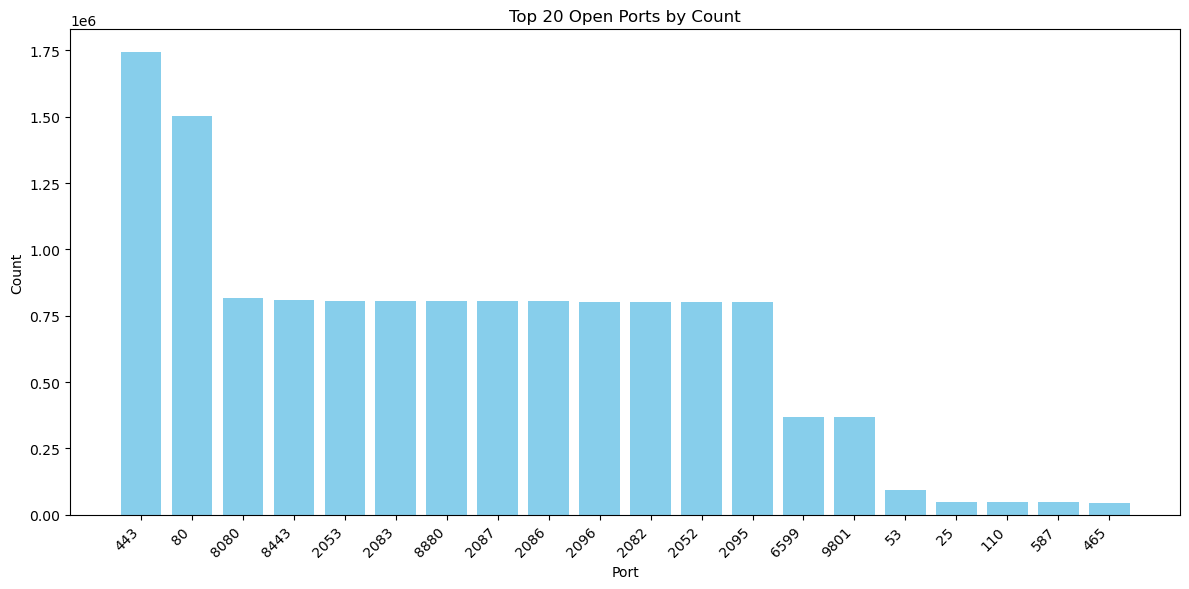

In [17]:
port_freq_pd = port_freq.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(port_freq_pd["ports"].astype(str), port_freq_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Port")
plt.ylabel("Count")
plt.title("Top 20 Open Ports by Count")
plt.tight_layout()
plt.show()

### 443 is the most used port, most likely due to the large amount of HTTP deployed. The group of ports that have similar counts are likely due to CDNs deploying over them on every IP 

Figure out how nmap works to explain why they find more services than I do

In [16]:
print(f"Total distinct ports: {port_freq.count()}")

Total distinct ports: 57904


In [74]:
# 172.65.64.119 has a very large number of services

censys_anycast.filter(
    psf.array_contains("port", 58000)
).select("host_identifier.ipv4", "port").show(truncate=True)

+---------------+--------------------+
|           ipv4|                port|
+---------------+--------------------+
|  172.65.64.119|[5060, 5061, 5071...|
|  172.65.64.113|[5002, 5039, 5060...|
|   172.65.42.79|[21, 22, 25, 43, ...|
|  170.33.13.171|[2, 21, 22, 23, 2...|
|  172.65.211.39|[40000, 40167, 40...|
|    170.33.8.87|[2, 21, 23, 25, 4...|
|  172.65.64.112|[5008, 5016, 5051...|
| 15.197.173.155|[16419, 16667, 17...|
|  43.159.28.111|[111, 5000, 5900,...|
|  172.65.64.116|[5028, 5032, 5043...|
|   170.33.13.59|[2, 21, 22, 23, 2...|
|    171.7.64.22|[2, 21, 25, 43, 5...|
| 172.65.240.171|[2, 21, 22, 23, 2...|
| 172.65.227.155|[2, 10, 13, 15, 2...|
|    171.6.0.226|[2, 21, 25, 81, 8...|
| 172.65.217.218|[2, 21, 22, 23, 2...|
|103.240.228.123|             [58000]|
| 213.215.161.37|[80, 58000, 58006...|
|   171.7.64.206|[2, 17, 21, 22, 2...|
|  172.65.64.115|[5053, 5055, 5060...|
+---------------+--------------------+
only showing top 20 rows



In [33]:
censys_anycast \
    .filter(censys_anycast["host_identifier.ipv4"] == "172.65.64.119") \
    .select("host_identifier.ipv4", psf.size("service_name").alias("service_count")) \
    .show()
print("Distinct services")
censys_anycast \
    .filter(censys_anycast["host_identifier.ipv4"] == "172.65.64.119") \
    .select("host_identifier.ipv4", psf.size(psf.array_distinct("service_name")).alias("service_count")) \
    .show()

+-------------+-------------+
|         ipv4|service_count|
+-------------+-------------+
|172.65.64.119|         3169|
+-------------+-------------+

Distinct services
+-------------+-------------+
|         ipv4|service_count|
+-------------+-------------+
|172.65.64.119|            2|
+-------------+-------------+



# Aggregating services and IPs per /24 prefix

In [18]:
# Adds up all the distinct services of all the IPs per prefix, and keeps count of how many IPs exist in that prefix with ip_count
aggregated = censys_anycast.select(
    "prefix",
    psf.col("host_identifier.ipv4").alias("ipv4"),
    psf.col("autonomous_system.asn").alias("asn"),
    psf.explode(
        psf.array_distinct("service_name")
    ).alias("service")
).groupBy("prefix").agg(
    psf.collect_set("service").alias("distinct_services"),
    psf.countDistinct("ipv4").alias("ip_count"),
    psf.collect_set("asn").alias("asn_set")
).persist(StorageLevel.MEMORY_AND_DISK)


In [19]:
aggregated.show(50, truncate=False)

+----------------+---------------------+--------+--------+
|prefix          |distinct_services    |ip_count|asn_set |
+----------------+---------------------+--------+--------+
|101.32.132.0/24 |[MQTT, UNKNOWN, HTTP]|2       |[132203]|
|104.16.105.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.11.0/24  |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.110.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.111.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.112.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.141.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.154.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.172.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.183.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.193.0/24 |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.3.0/24   |[UNKNOWN, HTTP]      |256     |[13335] |
|104.16.66.0/24  |[UNKNOWN, HTTP]      |256     |[13335] |
|104.17.1.0/24   |[UNKNOWN, HTTP]      |256     |[13335]

In [57]:
aggregated.filter(aggregated["ip_count"] == 5).show(truncate=False)

+----------------+-----------------------------------------------------------------------------------+--------+
|prefix          |distinct_services                                                                  |ip_count|
+----------------+-----------------------------------------------------------------------------------+--------+
|185.71.138.0/24 |[UNKNOWN, HTTP]                                                                    |5       |
|23.53.5.0/24    |[HTTP]                                                                             |5       |
|65.22.66.0/24   |[DNS]                                                                              |5       |
|65.22.84.0/24   |[DNS]                                                                              |5       |
|93.188.0.0/24   |[BGP, DNS]                                                                         |5       |
|185.223.45.0/24 |[DNS, HTTP]                                                                        |5 

In [77]:
# Filter if data about a specific prefix is needed
aggregated.filter(aggregated["prefix"] == "1.2.3.0/24").show(truncate=False)

+------+-----------------+--------+-------+
|prefix|distinct_services|ip_count|asn_set|
+------+-----------------+--------+-------+
+------+-----------------+--------+-------+



In [50]:
# Adds a column to the bins so that the plotted chart is in the correct order.
def get_ip_bin_counts(df):
    binned = df.withColumn(
        "ip_bin",
        psf.when(df.ip_count == 256, "256")
        .when(df.ip_count == 1, "1")
        .when((df.ip_count > 1) & (df.ip_count <= 50), "2-50")
        .when((df.ip_count > 50) & (df.ip_count <= 150), "51-150")
        .when((df.ip_count > 150) & (df.ip_count < 256), "151-255")
    )

    # Add bin_order to binned so it can be used later
    binned = binned.withColumn(
        "bin_order",
        psf.when(psf.col("ip_bin") == "256", 0)
        .when(psf.col("ip_bin") == "151-255", 1)
        .when(psf.col("ip_bin") == "51-150", 2)
        .when(psf.col("ip_bin") == "2-50", 3)
        .when(psf.col("ip_bin") == "1", 4)
    )

    # Count occurrences per bin
    bin_counts = binned.groupBy("ip_bin", "bin_order").count()

    return bin_counts.orderBy("bin_order")

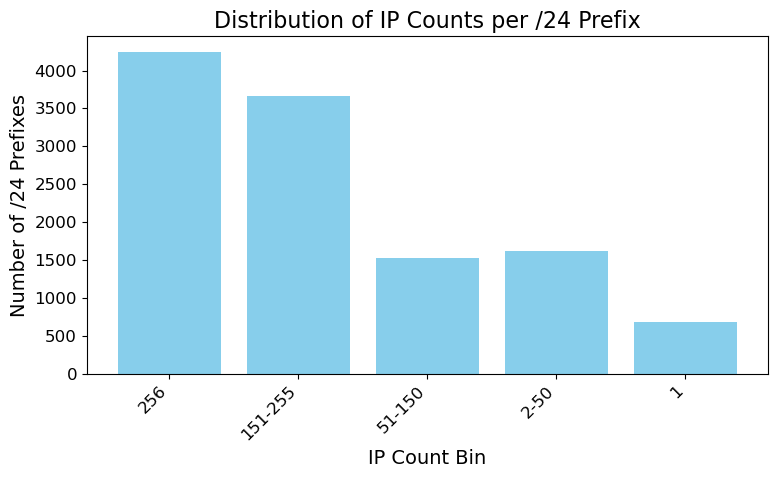

In [51]:
ip_bin_counts_pd = get_ip_bin_counts(aggregated).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(ip_bin_counts_pd["ip_bin"], ip_bin_counts_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Very important graph, shows that a majority of prefixes utilize most/every IP address within them. Likely done due to a lazy deployment.

In [86]:
print("Total in bins: ", ip_bin_counts.agg(psf.sum("count")).collect()[0][0])
print("Total prefixes: ", aggregated.count())

Total in bins:  11720
Total prefixes:  11720


In [73]:
aggregated.filter((psf.col("ip_count") >= 151) & (psf.col("ip_count") < 256)).count()

3660

In [101]:
aggregated.filter(psf.col("ip_count") >= 5).count()

10344

In [105]:
# Finding how many AS'es have 5 or more IPs, for comparison with old study
aggregated.filter(psf.col("ip_count") >= 5) \
          .select(psf.explode("asn_set").alias("asn")) \
          .distinct() \
          .count()

425

In [108]:
aggregated.filter(psf.array_contains("asn_set", 396982)).count() # Number of /24 by google 

3351

In [90]:
censys_anycast \S # Checking a spesific prefix for MYSQL
    .filter((psf.col("prefix") == "85.128.147.0/24") & psf.array_contains("service_name", "MYSQL")) \
    .select("host_identifier.ipv4", "service_name") \
    .show(truncate=False)

+--------------+----------------------------------------------------------------------------------------+
|ipv4          |service_name                                                                            |
+--------------+----------------------------------------------------------------------------------------+
|85.128.147.81 |[FTP, SMTP, HTTP, POP3, IMAP, HTTP, SMTP, SMTP, IMAP, POP3, MYSQL, MYSQL, POSTGRES]     |
|85.128.147.22 |[FTP, SMTP, HTTP, POP3, IMAP, HTTP, SMTP, SMTP, IMAP, POP3, MYSQL, MYSQL, POSTGRES]     |
|85.128.147.59 |[FTP, SMTP, HTTP, POP3, IMAP, HTTP, SMTP, SMTP, IMAP, POP3, MYSQL, MYSQL, POSTGRES]     |
|85.128.147.209|[FTP, SMTP, HTTP, POP3, IMAP, HTTP, SMTP, SMTP, IMAP, POP3, MYSQL, MYSQL, POSTGRES]     |
|85.128.147.241|[FTP, SMTP, HTTP, POP3, IMAP, HTTP, SMTP, SMTP, IMAP, POP3, MYSQL, MYSQL, POSTGRES]     |
|85.128.147.225|[FTP, SMTP, HTTP, POP3, IMAP, HTTP, SMTP, SMTP, IMAP, POP3, MYSQL, MYSQL, POSTGRES]     |
|85.128.147.49 |[FTP, SMTP, HTTP, POP3, IMAP, 

In [19]:
ip_count_distribution = aggregated.groupBy("ip_count").count().orderBy("ip_count")
ip_count_distribution.show(220, truncate=False)

+--------+-----+
|ip_count|count|
+--------+-----+
|1       |683  |
|2       |317  |
|3       |129  |
|4       |247  |
|5       |167  |
|6       |85   |
|7       |62   |
|8       |44   |
|9       |22   |
|10      |68   |
|11      |32   |
|12      |30   |
|13      |16   |
|14      |28   |
|15      |13   |
|16      |46   |
|17      |23   |
|18      |12   |
|19      |14   |
|20      |17   |
|21      |11   |
|22      |7    |
|23      |9    |
|24      |21   |
|25      |9    |
|26      |11   |
|27      |7    |
|28      |6    |
|29      |9    |
|30      |8    |
|31      |26   |
|32      |15   |
|33      |5    |
|34      |5    |
|35      |3    |
|36      |6    |
|37      |3    |
|38      |4    |
|39      |2    |
|40      |10   |
|41      |4    |
|42      |4    |
|43      |5    |
|44      |4    |
|45      |4    |
|46      |9    |
|47      |5    |
|48      |16   |
|49      |5    |
|50      |11   |
|51      |3    |
|52      |8    |
|53      |4    |
|54      |7    |
|55      |6    |
|56      |4   

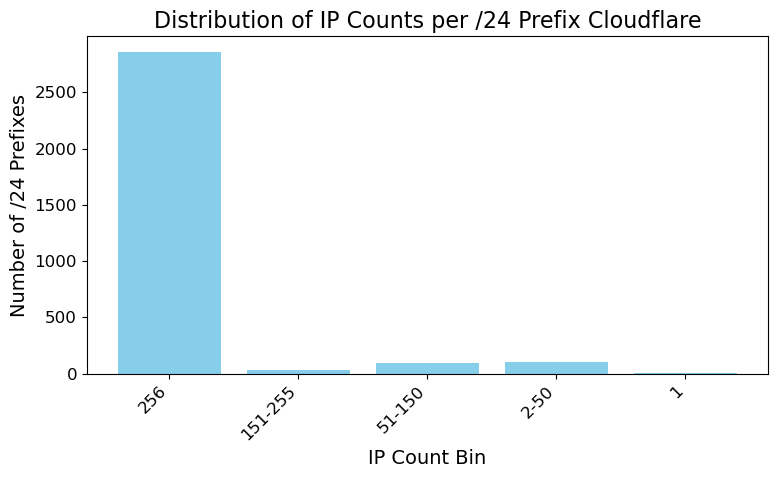

In [52]:
aggregated_cloudflare = aggregated.filter(psf.array_contains("asn_set", 13335))
bins_cloudflare_pd = get_ip_bin_counts(aggregated_cloudflare).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_cloudflare_pd["ip_bin"], bins_cloudflare_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Cloudflare")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

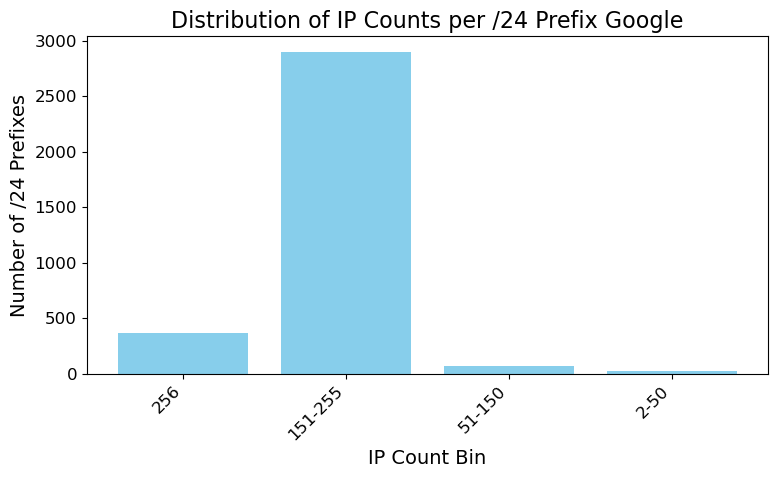

In [53]:
aggregated_google = aggregated.filter(psf.array_contains("asn_set", 396982))
bins_google_pd = get_ip_bin_counts(aggregated_google).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_google_pd["ip_bin"], bins_google_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Google")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

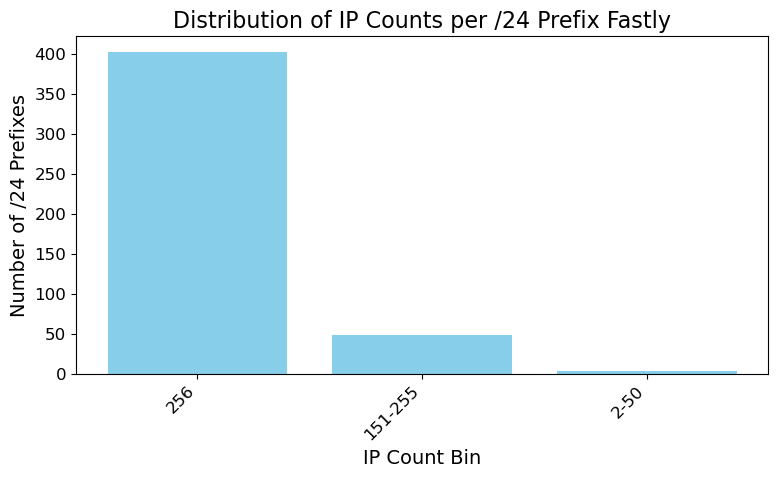

In [54]:
aggregated_fastly = aggregated.filter(psf.array_contains("asn_set", 54113))
bins_fastly_pd = get_ip_bin_counts(aggregated_fastly).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_fastly_pd["ip_bin"], bins_fastly_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Fastly")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

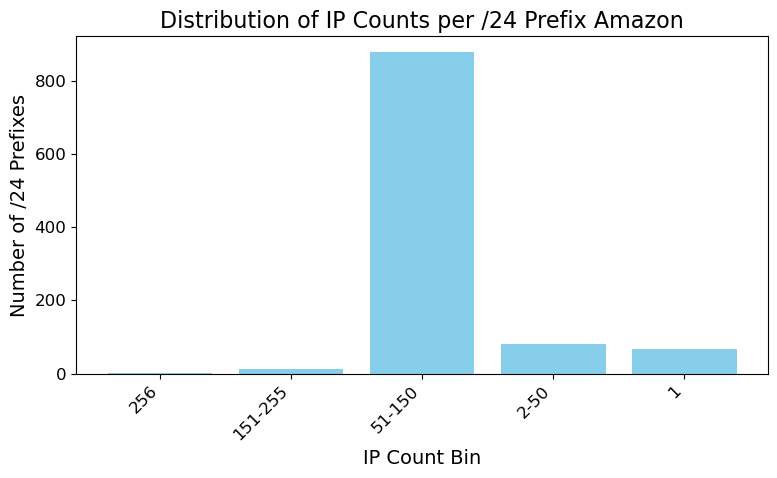

In [55]:
aggregated_amazon = aggregated.filter(psf.array_contains("asn_set", 16509))
bins_amazon_pd = get_ip_bin_counts(aggregated_amazon).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_amazon_pd["ip_bin"], bins_amazon_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Amazon")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

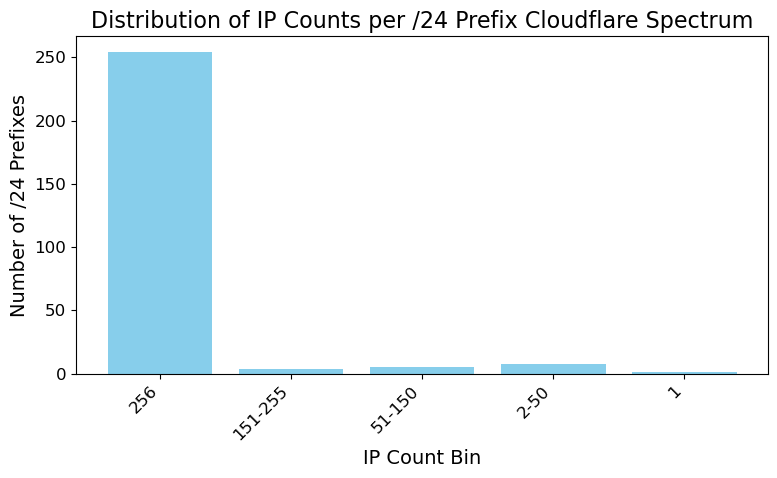

In [56]:
aggregated_cloudflarespec = aggregated.filter(psf.array_contains("asn_set", 209242))
bins_cloudflarespec_pd = get_ip_bin_counts(aggregated_cloudflarespec).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_cloudflarespec_pd["ip_bin"], bins_cloudflarespec_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Cloudflare Spectrum")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

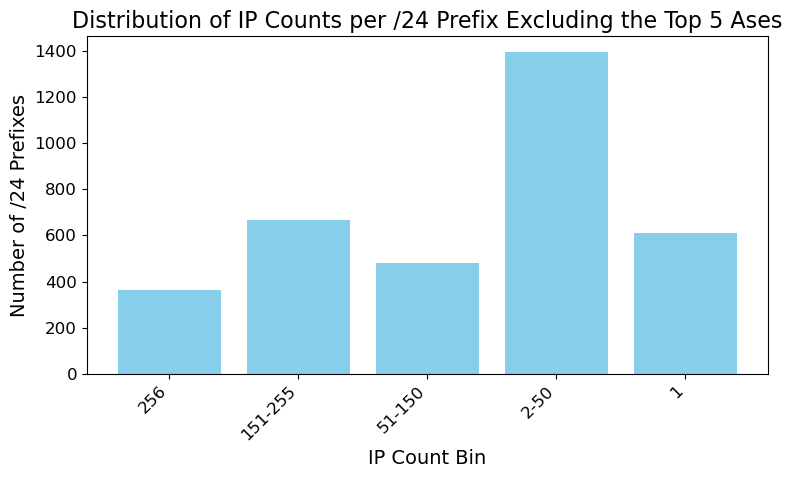

In [57]:
excluded_asns = [396982, 13335, 54113, 16509, 209242]

filtered_df = aggregated
for asn in excluded_asns:
    filtered_df = filtered_df.filter(~psf.array_contains("asn_set", asn))

bins_filtered_pd = get_ip_bin_counts(filtered_df).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_filtered_pd["ip_bin"], bins_filtered_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Excluding the Top 5 Ases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

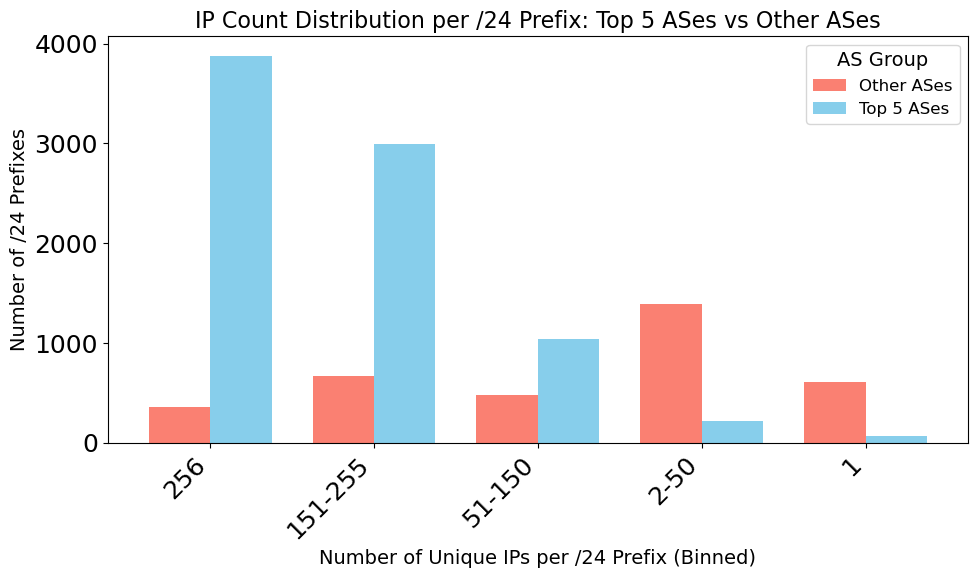

In [121]:
bin_order = ["256", "151-255", "51-150", "2-50", "1"]

# Combine the top 5 into one dataframe
top5_df = pd.concat([
    bins_cloudflare_pd,
    bins_google_pd,
    bins_fastly_pd,
    bins_amazon_pd,
    bins_cloudflarespec_pd
])

# Sum counts per bin for each group
top5_grouped = top5_df.groupby('ip_bin')['count'].sum().reset_index()
top5_grouped['group'] = 'Top 5 ASes'

non_top5_grouped = bins_filtered_pd.groupby('ip_bin')['count'].sum().reset_index()
non_top5_grouped['group'] = 'Other ASes'

# Combine both groups
combined = pd.concat([top5_grouped, non_top5_grouped])

# Ensure ip_bin is ordered correctly
combined['ip_bin'] = pd.Categorical(combined['ip_bin'], categories=bin_order, ordered=True)

# Pivot for plotting with actual counts
pivot_df = combined.pivot(index='ip_bin', columns='group', values='count').fillna(0)
pivot_df = pivot_df.sort_index()

# Plot
ax = pivot_df.plot(kind='bar', figsize=(10, 6), width=0.75, color=['salmon', 'skyblue'])
ax.tick_params(labelsize=18)
plt.ylabel("Number of /24 Prefixes")
plt.xlabel("Number of Unique IPs per /24 Prefix (Binned)")
plt.title("IP Count Distribution per /24 Prefix: Top 5 ASes vs Other ASes")
plt.legend(title="AS Group")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/IP_Count_dist.pdf", bbox_inches='tight')
plt.show()

# Checking how many http titles per prefix are unique

In [11]:
http_titles_per_prefix = censys_anycast \
    .filter(psf.array_contains("port", 443)) \
    .filter(psf.col("headers").isNotNull()) \
    .groupBy("prefix") \
    .agg(psf.countDistinct("headers").alias("unique_http_headers"))

In [12]:
http_titles_per_prefix.filter(psf.col("prefix") == "172.65.64.0/24").show(truncate=False)

+--------------+-------------------+
|prefix        |unique_http_headers|
+--------------+-------------------+
|172.65.64.0/24|17                 |
+--------------+-------------------+



In [15]:
header_diversity_distribution = http_titles_per_prefix \
    .groupBy("unique_http_headers") \
    .count() \
    .orderBy("unique_http_headers")

header_diversity_distribution.show(220, truncate=False)

+-------------------+-----+
|unique_http_headers|count|
+-------------------+-----+
|1                  |488  |
|2                  |282  |
|3                  |197  |
|4                  |183  |
|5                  |120  |
|6                  |62   |
|7                  |44   |
|8                  |55   |
|9                  |33   |
|10                 |39   |
|11                 |24   |
|12                 |15   |
|13                 |17   |
|14                 |10   |
|15                 |12   |
|16                 |10   |
|17                 |18   |
|18                 |7    |
|19                 |14   |
|20                 |17   |
|21                 |8    |
|22                 |7    |
|23                 |10   |
|24                 |11   |
|25                 |9    |
|26                 |12   |
|27                 |12   |
|28                 |6    |
|29                 |15   |
|30                 |14   |
|31                 |7    |
|32                 |6    |
|33                 

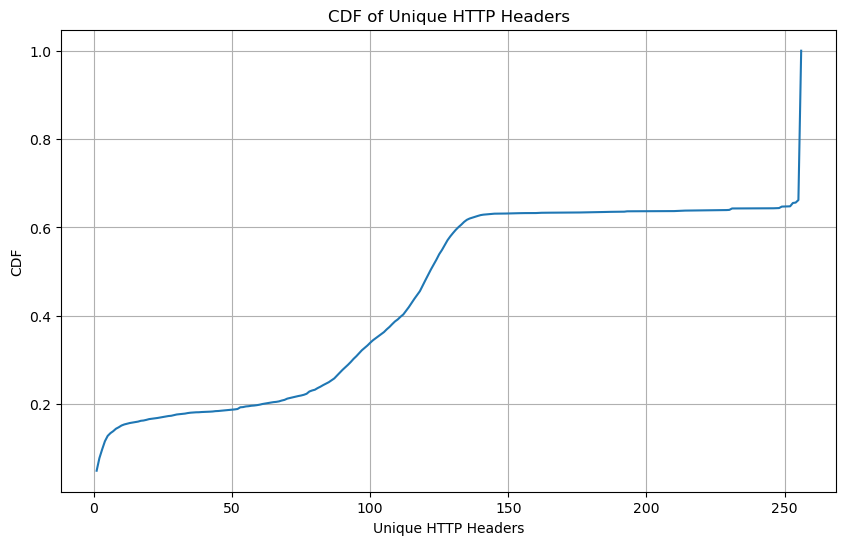

In [123]:
# plot using a CDF
header_distribution_pd = header_diversity_distribution.toPandas()
header_distribution_pd["cdf"] = header_distribution_pd["count"].cumsum() / header_distribution_pd["count"].sum()

plt.figure(figsize=(10, 6))
plt.plot(header_distribution_pd["unique_http_headers"], header_distribution_pd["cdf"], linestyle='-', marker=None)
plt.title("CDF of Unique HTTP Headers")
plt.xlabel("Unique HTTP Headers")
plt.ylabel("CDF")
plt.grid(True)
plt.show()

In [14]:
distinct_levels = header_diversity_distribution.select("unique_http_headers").distinct().count()
print(f"Number of unique header diversity levels: {distinct_levels}")

Number of unique header diversity levels: 205


# Plotting services after aggregating by unique per prefix

<span style="color:red">Comparison graphs from here on will require the corresponding AS graph from the service analysis section to be run</span>

In [115]:
def plot_service_comparison(aggregated_dist_pd, ip_df_pd, asn_label="Unknown ASN"):
    org_name = asn_label.split(" (ASN")[0].replace(' ', '_')

    
    
    # Find common services
    common_services = list(set(aggregated_dist_pd["service"]) & set(ip_df_pd["service"]))

    # Filter and align
    prefix_df = aggregated_dist_pd[aggregated_dist_pd["service"].isin(common_services)].copy()
    count_df = ip_df_pd[ip_df_pd["service"].isin(common_services)].copy() # this is for unique ips

    # Merge to align by service
    merged_df = prefix_df.merge(count_df, on="service", suffixes=('_prefix', '_count'))

    merged_df = merged_df.sort_values("count_count", ascending=False).head(10)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    bar_width = 0.4
    x = np.arange(len(merged_df))

    ax.bar(x - bar_width/2, merged_df["count_prefix"], width=bar_width, label="Prefixes", color='skyblue')
    ax.bar(x + bar_width/2, merged_df["count_count"], width=bar_width, label="Unique IPs", color='salmon')
    ax.set_yscale("log")
    ax.set_ylabel("Count (Log Scale)")
    ax.set_title(f"Service Spread vs. Density - {asn_label}")
    ax.set_xticks(x)
    ax.tick_params(labelsize=20)
    ax.set_xticklabels(merged_df["service"], rotation=45, ha='right')
    plt.legend()

    plt.savefig(f"output/{org_name}_service_dist.pdf", bbox_inches='tight')
    plt.show()

In [20]:
aggregated_cloudflare = aggregated.filter(psf.array_contains("asn_set", 13335))
service_distribution_cf = aggregated_cloudflare \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

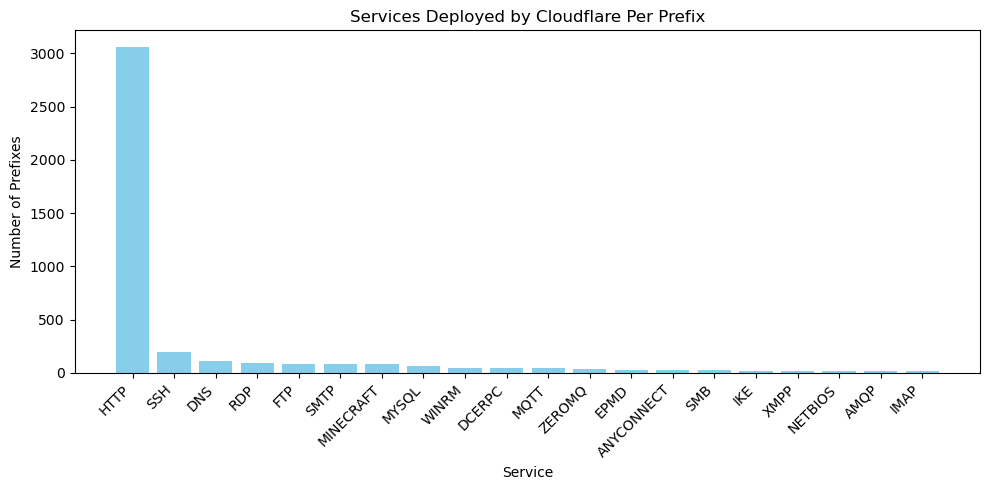

In [21]:
dist_cf_pd = service_distribution_cf.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_cf_pd["service"], dist_cf_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Cloudflare Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

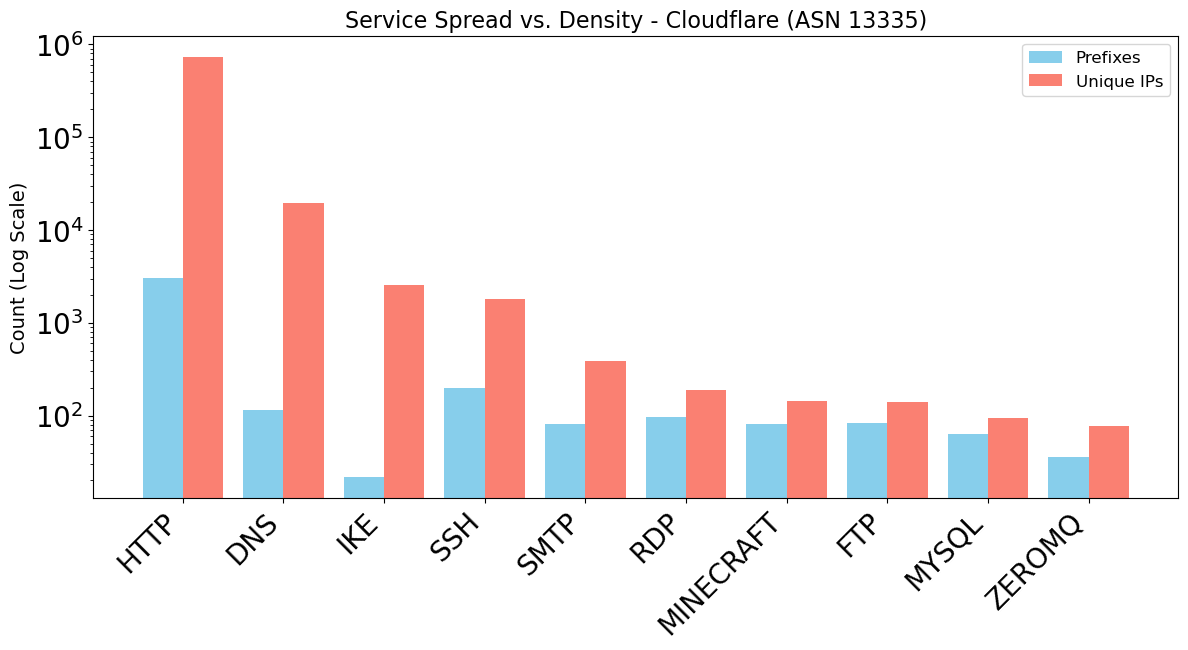

In [116]:
# As a reminder, service_cloudflare_pd is from the Service Analysis section, where the top 20 services deployed by cloudflare are found
plot_service_comparison(dist_cf_pd, service_cloudflare_pd, asn_label="Cloudflare (ASN 13335)")

IKE likely used for DDos protection by cloudflare magic transit - hypothesis + future work

In [23]:
aggregated_google = aggregated.filter(psf.array_contains("asn_set", 396982)) # Google Cloud
service_distribution_gc = aggregated_google \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

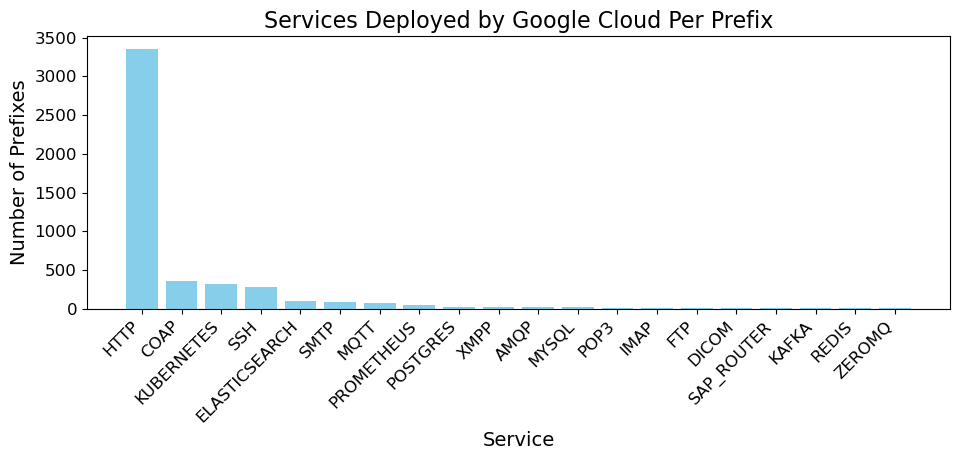

In [24]:
dist_gc_pd = service_distribution_gc.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_gc_pd["service"], dist_gc_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Google Cloud Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

          service  count_prefix  count_count
0            HTTP          3351       823110
1            COAP           363          388
2      KUBERNETES           318          369
3             SSH           279          390
4   ELASTICSEARCH            95           96
5            SMTP            87           93
6            MQTT            73           73
7      PROMETHEUS            44           44
8        POSTGRES            28           29
9            XMPP            24           24
10           AMQP            23           23
11          MYSQL            22           22
12           POP3            11           11
13           IMAP            11           11
14            FTP             9            9
15          DICOM             7            7
16     SAP_ROUTER             7            7
17          KAFKA             6            6


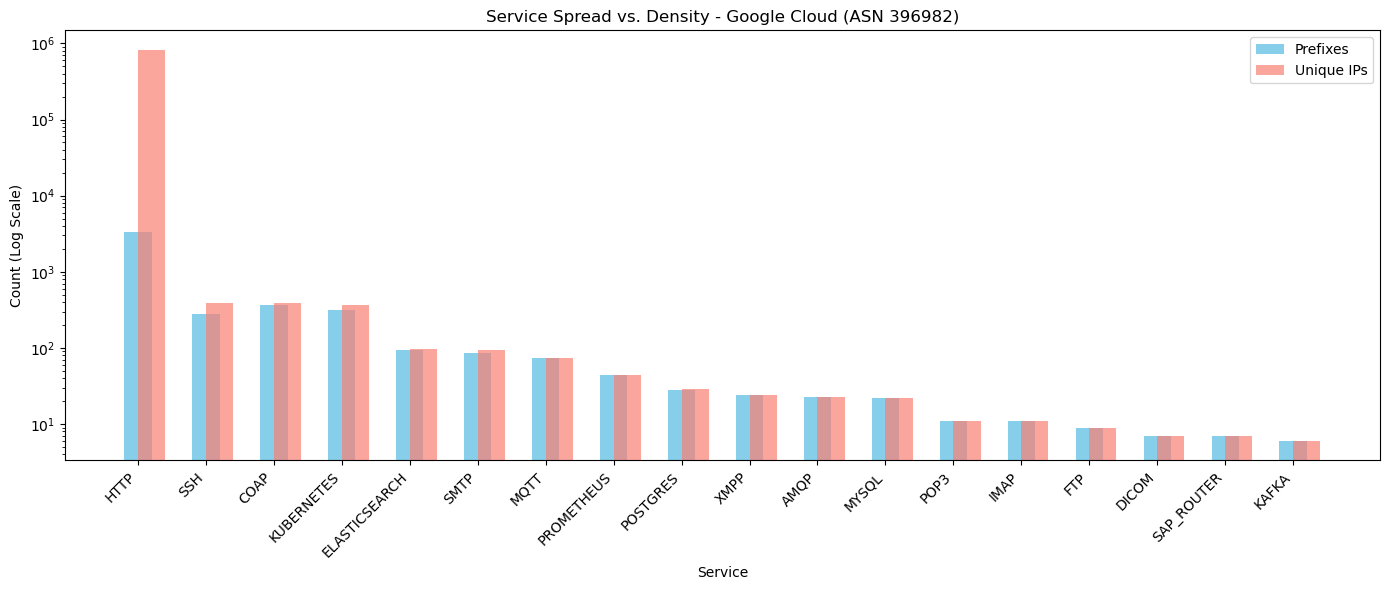

In [98]:
plot_service_comparison(dist_gc_pd,service_google_pd, asn_label="Google Cloud (ASN 396982)")

In [25]:
aggregated_fastly = aggregated.filter(psf.array_contains("asn_set", 54113)) # Fastly
service_distribution_fa = aggregated_fastly \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

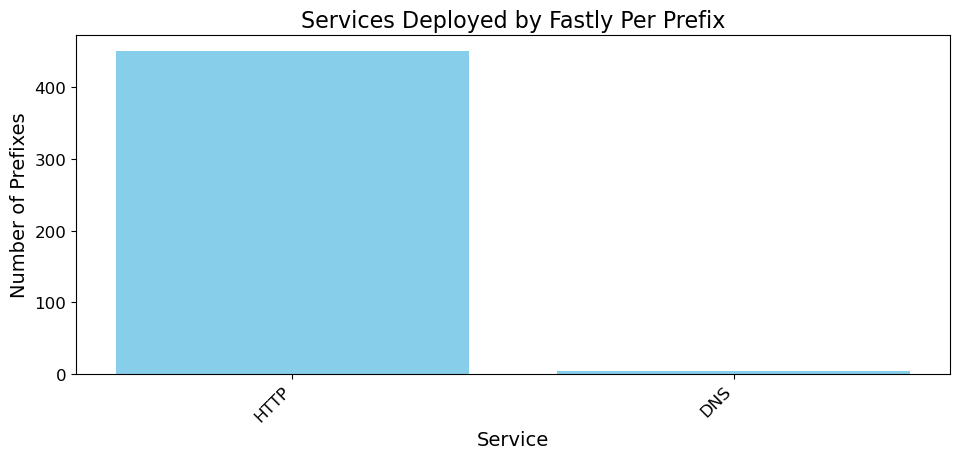

In [26]:
dist_fa_pd = service_distribution_fa.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_fa_pd["service"], dist_fa_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Fastly Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

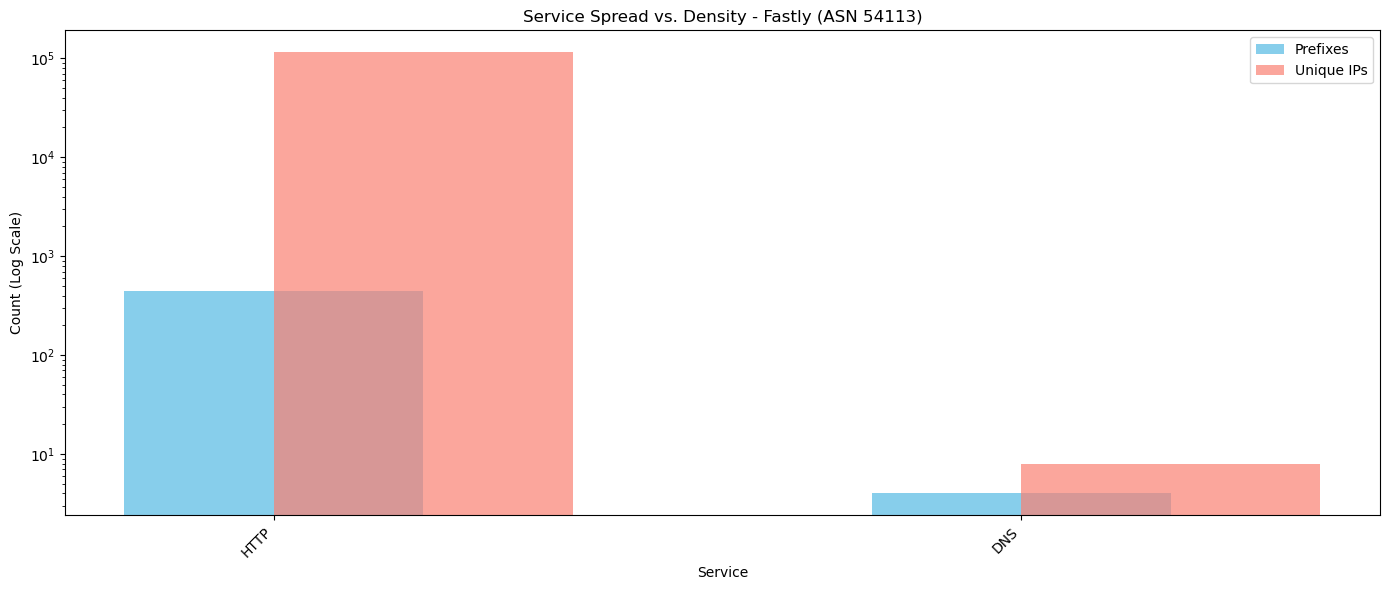

In [75]:
plot_service_comparison(dist_fa_pd,service_fastly_pd, asn_label="Fastly (ASN 54113)")

In [27]:
aggregated_amazon = aggregated.filter(psf.array_contains("asn_set", 16509)) # Amazon
service_distribution_am = aggregated_amazon \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

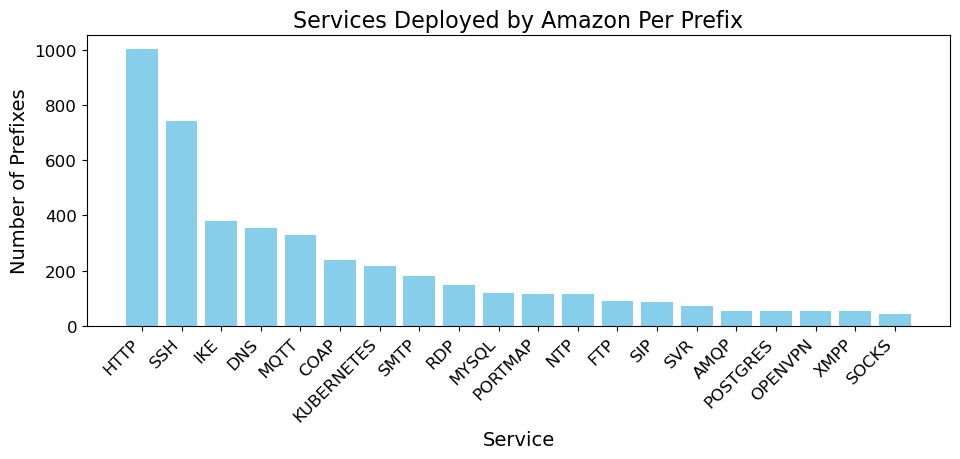

In [28]:
dist_am_pd = service_distribution_am.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_am_pd["service"], dist_am_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Amazon Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

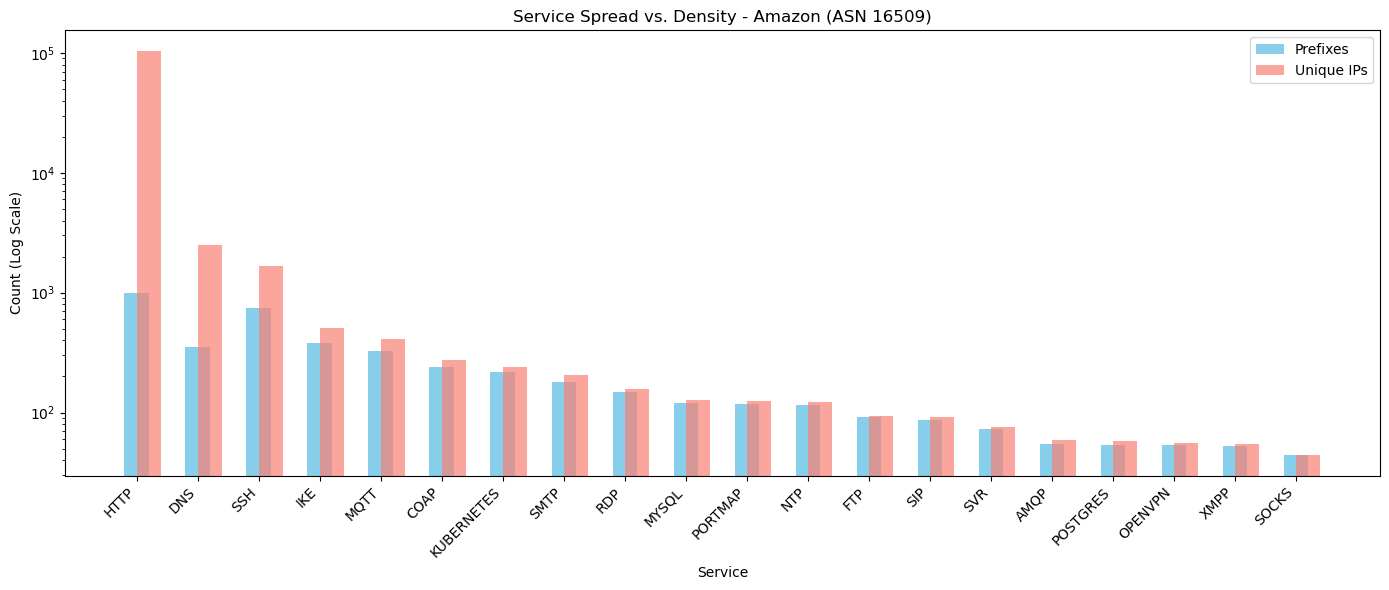

In [84]:
plot_service_comparison(dist_am_pd,service_amazon_pd, asn_label="Amazon (ASN 16509)")

In [29]:
aggregated_cloudflarespec = aggregated.filter(psf.array_contains("asn_set", 209242)) # Cloudflare Spectrum
service_distribution_cfs = aggregated_cloudflarespec \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

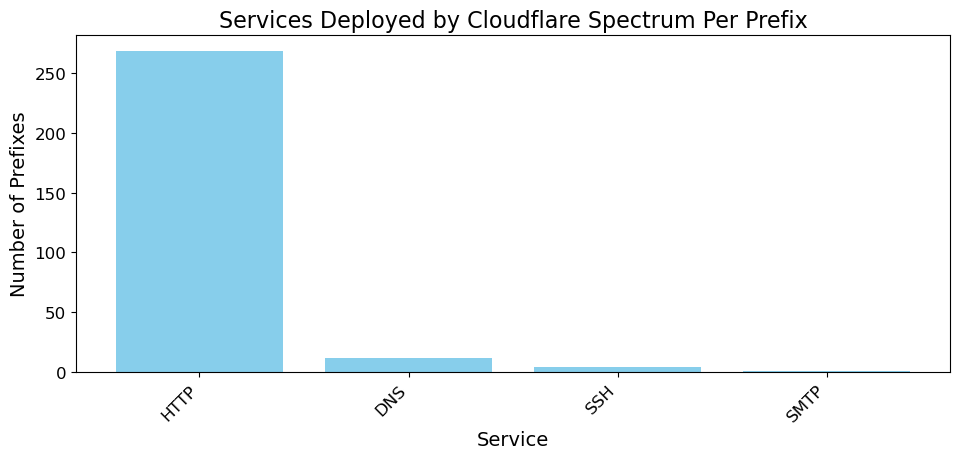

In [30]:
dist_cfs_pd = service_distribution_cfs.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_cfs_pd["service"], dist_cfs_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Cloudflare Spectrum Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

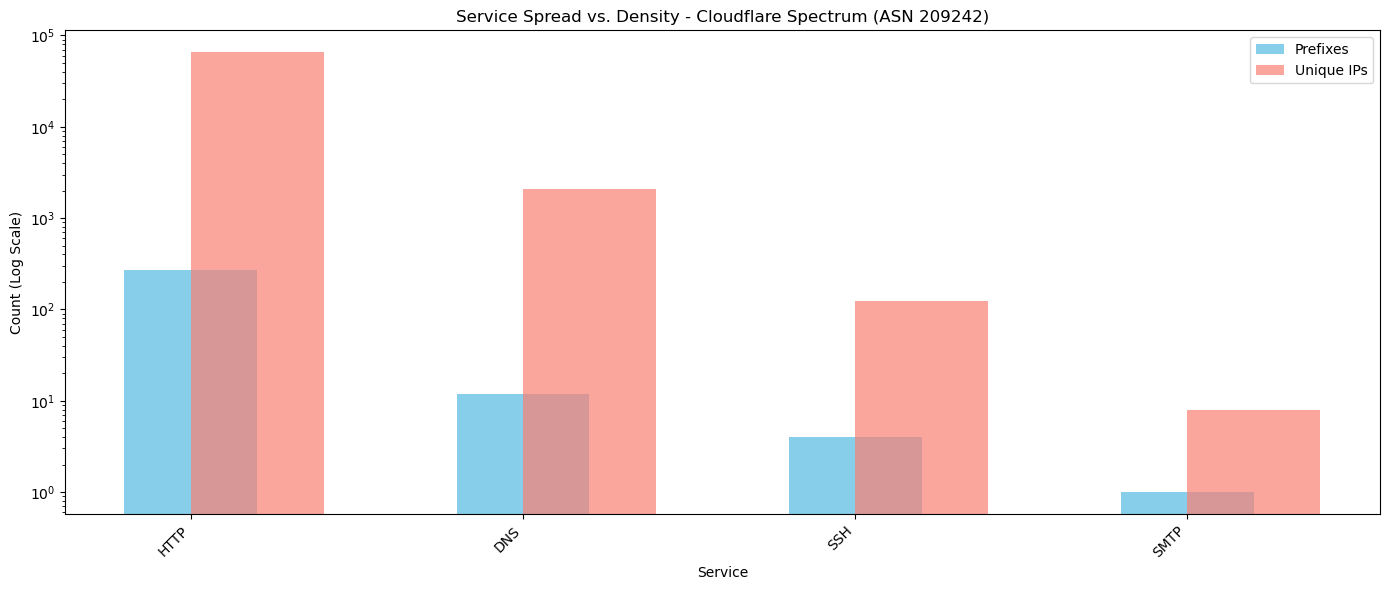

In [90]:
plot_service_comparison(dist_cfs_pd,service_cloudflarespec_pd, asn_label="Cloudflare Spectrum (ASN 209242)")

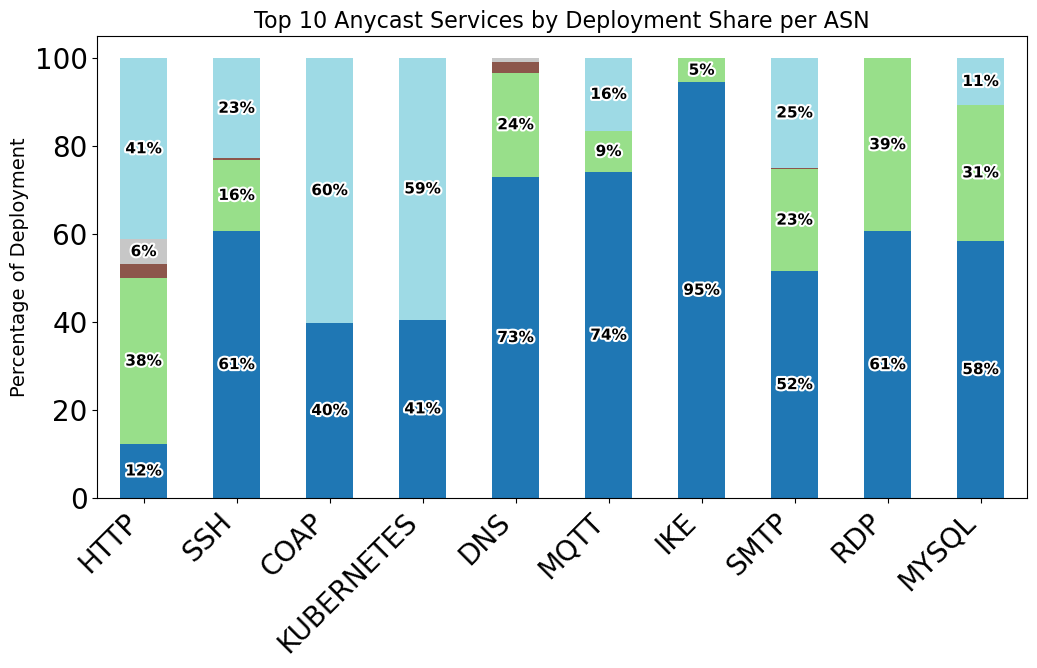

In [144]:
dist_cf_pd["asn"] = "Cloudflare"
dist_gc_pd["asn"] = "Google"
dist_fa_pd["asn"] = "Fastly"
dist_am_pd["asn"] = "Amazon"
dist_cfs_pd["asn"] = "Cloudflare Spectrum"

# Combine all into one
combined = pd.concat([dist_cf_pd, dist_gc_pd, dist_fa_pd, dist_am_pd, dist_cfs_pd])

# Pivot to get service x ASN
pivot = combined.pivot_table(index="service", columns="asn", values="count", fill_value=0)

# Determine top 10 services by total count
top10_services = pivot.sum(axis=1).nlargest(10).index

# Filter to top 10
pivot_top = pivot.loc[top10_services]

# Normalize across rows (i.e., for each service, show AS contributions as %)
pivot_pct = pivot_top.div(pivot_top.sum(axis=1), axis=0) * 100


ax = pivot_pct.plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="tab20",
)
ax.legend_.remove()
ax.set_xlabel("")
plt.ylabel("Percentage of Deployment")
plt.title("Top 10 Anycast Services by Deployment Share per ASN")
plt.xticks(rotation=45, ha='right')
ax.tick_params(labelsize=20)


# Add bold percentage labels to segments >= 5%
for i, service in enumerate(pivot_pct.index):
    y_offset = 0
    for asn in pivot_pct.columns:
        height = pivot_pct.loc[service, asn]
        if height >= 5:
            ax.text(
                i, y_offset + height / 2,
                f"{height:.0f}%",
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                path_effects=[
                    path_effects.Stroke(linewidth=3, foreground='white'),
                    path_effects.Normal()
                ]
            )
        y_offset += height

plt.savefig("output/top5_deployment.pdf", bbox_inches='tight')

plt.show()

In [91]:
excluded_asns = [396982, 13335, 54113, 16509, 209242]

filtered_df_serv = aggregated
for asn in excluded_asns:
    filtered_df_serv = filtered_df_serv.filter(~psf.array_contains("asn_set", asn))

service_distribution_rest = filtered_df_serv \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

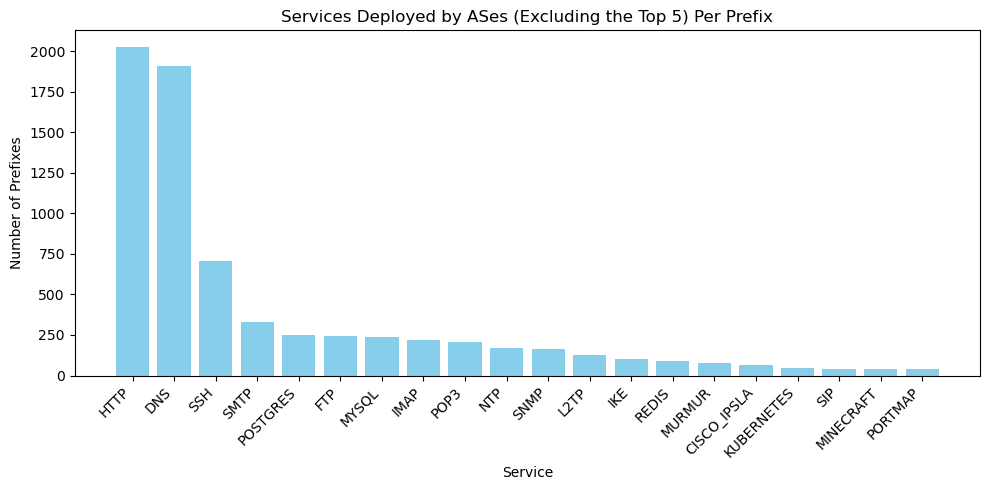

In [93]:
dist_rest_pd = service_distribution_rest.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_rest_pd["service"], dist_rest_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by ASes (Excluding the Top 5) Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

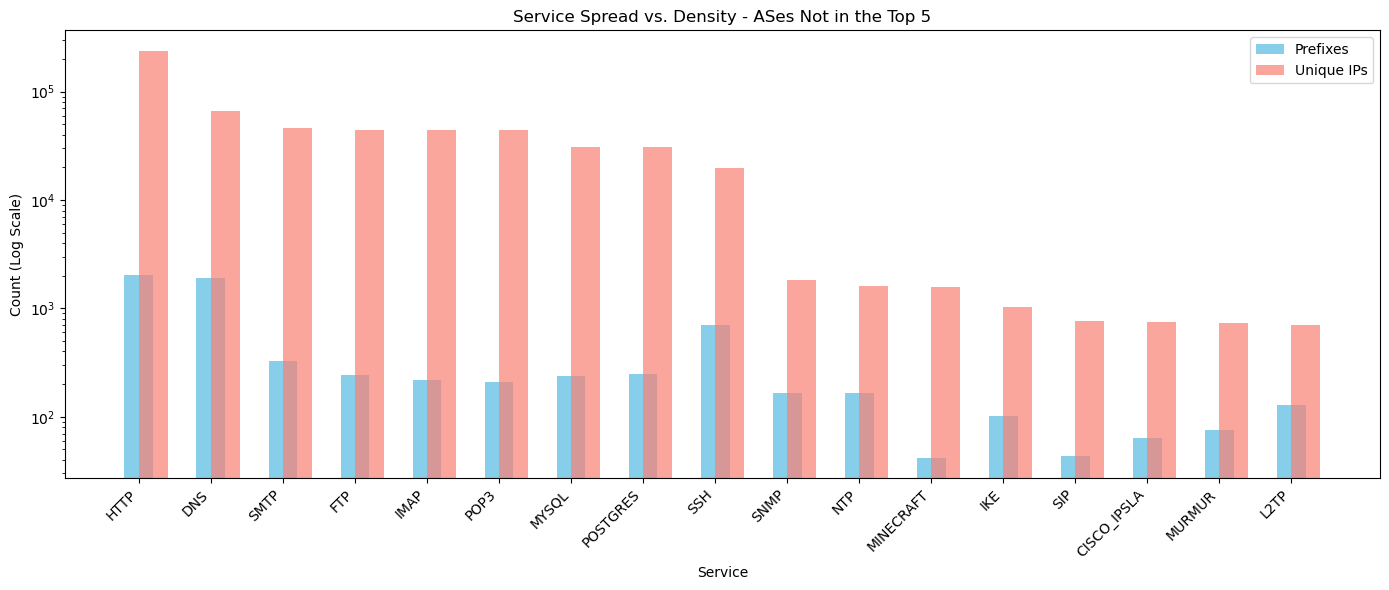

In [96]:
plot_service_comparison(dist_rest_pd,service_other_pd, asn_label="ASes Not in the Top 5")

# Categorizing operators

In [42]:
ip_location_df.printSchema()

root
 |-- ip: string (nullable = true)
 |-- ip_decimal: string (nullable = true)
 |-- cc: string (nullable = true)
 |-- c_name: string (nullable = true)
 |-- isp: string (nullable = true)
 |-- usage_type: string (nullable = true)



In [146]:
flattened_anycast = censys_anycast.withColumn("ipv4", psf.col("host_identifier.ipv4"))

enriched_anycast = flattened_anycast.join(
    ip_location_df.select("ip", "cc", "c_name", "isp", "usage_type"),
    psf.col("ipv4") == psf.col("ip"),
    how="left"
)

In [147]:
enriched_anycast.printSchema()

root
 |-- prefix: string (nullable = false)
 |-- count: long (nullable = true)
 |-- host_identifier: struct (nullable = true)
 |    |-- ipv4: string (nullable = true)
 |    |-- ipv6: string (nullable = true)
 |    |-- name: string (nullable = true)
 |-- port: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- transport: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- service_name: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- headers: array (nullable = true)
 |    |-- element: array (containsNull = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- key: string (nullable = true)
 |    |    |    |-- value: struct (nullable = true)
 |    |    |    |    |-- headers: array (nullable = true)
 |    |    |    |    |    |-- element: binary (containsNull = true)
 |-- autonomous_system: struct (nullable = true)
 |    |-- asn: long (nullable = true)
 |    |-- description: string (nullabl

In [45]:
enriched_anycast.filter(psf.col("ipv4") == "2.18.50.76") \
    .select("ipv4", "cc", "c_name", "isp", "usage_type") \
    .show(truncate=False)

+----------+---+-------+-----------------------+----------+
|ipv4      |cc |c_name |isp                    |usage_type|
+----------+---+-------+-----------------------+----------+
|2.18.50.76|BE |Belgium|Akamai International BV|CDN       |
+----------+---+-------+-----------------------+----------+



In [53]:
enriched_anycast.groupBy("usage_type").count().orderBy("count", ascending=False).show(truncate=False)

+----------+-------+
|usage_type|count  |
+----------+-------+
|DCH       |1227895|
|CDN       |920170 |
|COM       |21424  |
|ISP       |4935   |
|GOV       |1071   |
|MIL       |1024   |
|ORG       |881    |
|ISP/MOB   |818    |
|EDU       |816    |
|-         |767    |
|SES       |563    |
|RSV       |99     |
|MOB       |55     |
+----------+-------+



In [148]:
enriched_anycast \
    .select("usage_type", "autonomous_system.asn") \
    .distinct() \
    .groupBy("usage_type") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

+----------+-----+
|usage_type|count|
+----------+-----+
|DCH       |529  |
|ISP       |85   |
|COM       |66   |
|CDN       |38   |
|ISP/MOB   |18   |
|EDU       |14   |
|ORG       |13   |
|MOB       |5    |
|GOV       |5    |
|SES       |4    |
|-         |2    |
|RSV       |1    |
|MIL       |1    |
+----------+-----+



In [72]:
usage_ip_counts = enriched_anycast.groupBy("usage_type").count().toPandas()
asn_counts = enriched_anycast.select("usage_type", "autonomous_system.asn") \
    .distinct() \
    .groupBy("usage_type") \
    .count() \
    .withColumnRenamed("count", "asn_count") \
    .toPandas()

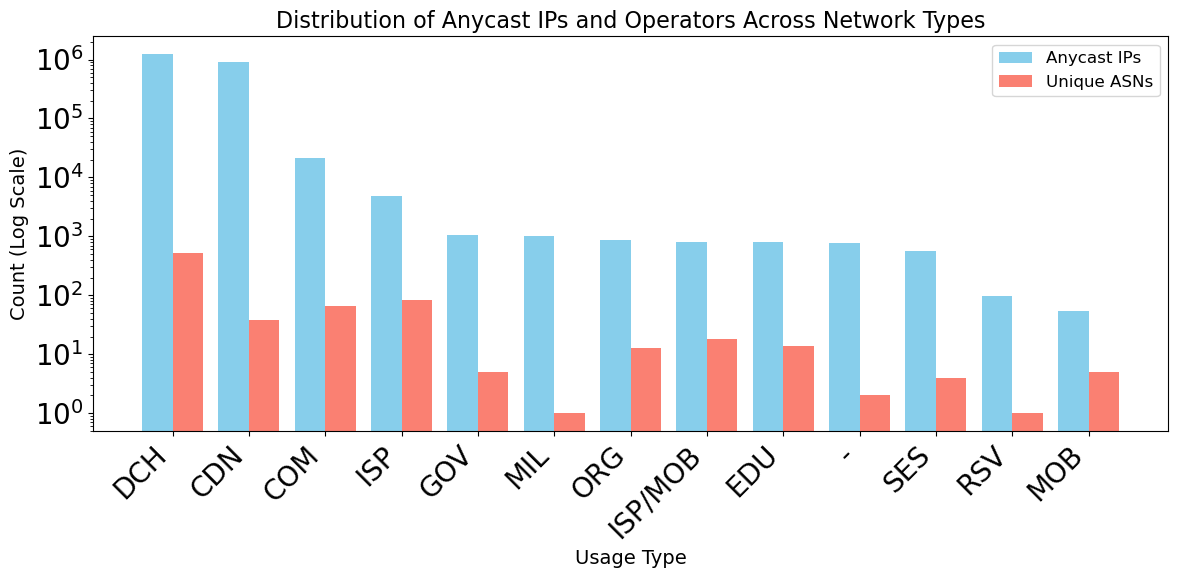

In [122]:
combined_df = usage_ip_counts.merge(asn_counts, on="usage_type")

combined_df = combined_df.sort_values("count", ascending=False)

x = np.arange(len(combined_df))  # label locations
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, combined_df["count"], width, label="Anycast IPs", color='skyblue')
ax.bar(x + width/2, combined_df["asn_count"], width, label="Unique ASNs", color='salmon')

ax.set_ylabel("Count (Log Scale)")
ax.set_yscale("log")
ax.set_xlabel("Usage Type")
ax.set_title("Distribution of Anycast IPs and Operators Across Network Types")
ax.set_xticks(x)
ax.set_xticklabels(combined_df["usage_type"], rotation=45, ha='right')
ax.legend()
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.savefig("output/Operator_dist.pdf", bbox_inches='tight')
plt.show()

Above graph shows comparison with IP addresses, not prefixes.

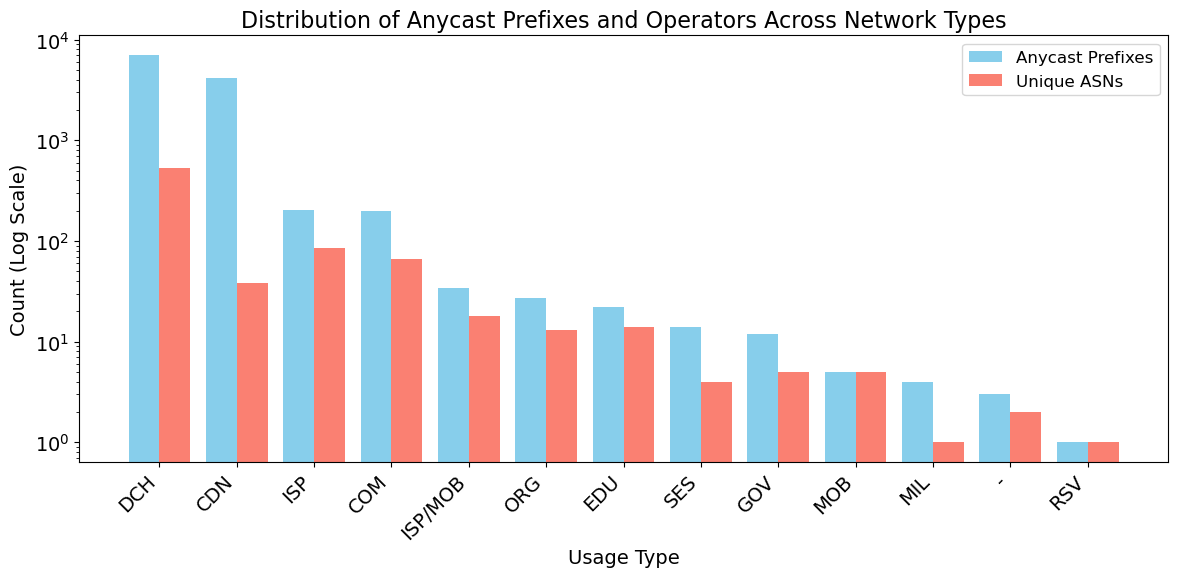

In [151]:
# Count unique prefixes per usage type
usage_prefix_counts = enriched_anycast.groupBy("usage_type") \
    .agg(psf.countDistinct("prefix").alias("prefix_count")) \
    .toPandas()

# Count unique ASNs per usage type
asn_counts = enriched_anycast.select("usage_type", "autonomous_system.asn") \
    .distinct() \
    .groupBy("usage_type") \
    .count() \
    .withColumnRenamed("count", "asn_count") \
    .toPandas()

# Merge the two dataframes
combined_df = usage_prefix_counts.merge(asn_counts, on="usage_type")

# Sort and prepare bar chart
combined_df = combined_df.sort_values("prefix_count", ascending=False)
x = np.arange(len(combined_df))
width = 0.4

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, combined_df["prefix_count"], width, label="Anycast Prefixes", color='skyblue')
ax.bar(x + width/2, combined_df["asn_count"], width, label="Unique ASNs", color='salmon')

ax.set_ylabel("Count (Log Scale)")
ax.set_yscale("log")
ax.set_xlabel("Usage Type")
ax.set_title("Distribution of Anycast Prefixes and Operators Across Network Types")
ax.set_xticks(x)
ax.set_xticklabels(combined_df["usage_type"], rotation=45, ha='right')
ax.tick_params(labelsize=14)
ax.legend()
plt.tight_layout()
plt.savefig("output/Operator_dist_prefix_based.pdf", bbox_inches='tight')
plt.show()

In [59]:
dch_asns = enriched_anycast \
    .filter(psf.col("usage_type") == "DCH") \
    .groupBy(
        psf.col("autonomous_system.asn").alias("asn"),
        psf.col("autonomous_system.name").alias("as_name"),
        psf.col("autonomous_system.organization").alias("organization")
    ) \
    .count() \
    .orderBy("count", ascending=False)

In [60]:
dch_asns.show(truncate=False)

+------+------------------------------------------+------------+------+
|asn   |as_name                                   |organization|count |
+------+------------------------------------------+------------+------+
|396982|GOOGLE-CLOUD-PLATFORM                     |NULL        |815058|
|16509 |AMAZON-02                                 |NULL        |112113|
|209242|CLOUDFLARESPECTRUM Cloudflare, Inc.       |NULL        |63713 |
|15169 |GOOGLE                                    |NULL        |50877 |
|15967 |NETARTGROUP                               |NULL        |46904 |
|207266|AFILIAS-SECONDARY-DNS                     |NULL        |19308 |
|55002 |DEFENSE-NET                               |NULL        |10526 |
|397218|SECURITYSERVICES                          |NULL        |7364  |
|25773 |RADWARE-CLOUD-SERVICES                    |NULL        |6386  |
|139341|ACE-AS-AP ACE                             |NULL        |5654  |
|54113 |FASTLY                                    |NULL        |

In [56]:
# Count total Anycast deployments per usage_type
usage_counts = enriched_anycast.groupBy("usage_type").count()

# Compute total
total_count = usage_counts.agg(psf.sum("count").alias("total")).collect()[0]["total"]

# Add percentage column
usage_pct = usage_counts.withColumn("percentage", (psf.col("count") / total_count) * 100)

# Sort and convert to pandas for plotting
usage_pct_pd = usage_pct.orderBy("percentage", ascending=False).toPandas()

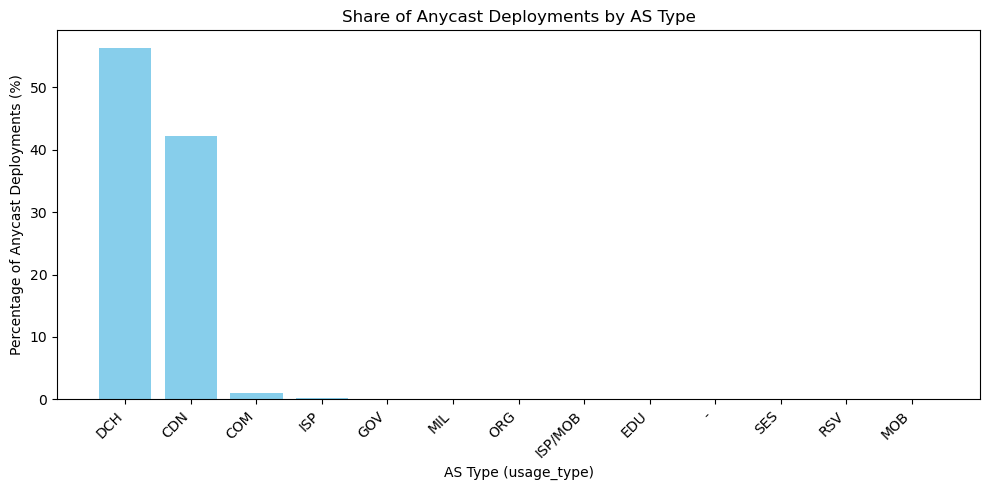

In [103]:
plt.figure(figsize=(10, 5))
plt.bar(usage_pct_pd["usage_type"], usage_pct_pd["percentage"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage of Anycast Deployments (%)")
plt.xlabel("AS Type (usage_type)")
plt.title("Share of Anycast Deployments by AS Type")
plt.tight_layout()
plt.show()

In [104]:
usage_counts.show(10, truncate=False)

+----------+-------+
|usage_type|count  |
+----------+-------+
|SES       |563    |
|COM       |21424  |
|ORG       |881    |
|EDU       |816    |
|ISP       |4935   |
|CDN       |920170 |
|-         |767    |
|DCH       |1227895|
|GOV       |1071   |
|ISP/MOB   |818    |
+----------+-------+
only showing top 10 rows



In [57]:
usage_pct.orderBy(psf.desc("count")).show(truncate = False)

+----------+-------+---------------------+
|usage_type|count  |percentage           |
+----------+-------+---------------------+
|DCH       |1227895|56.31207813923113    |
|CDN       |920170 |42.19960578174543    |
|COM       |21424  |0.9825188326810418   |
|ISP       |4935   |0.22632236927188862  |
|GOV       |1071   |0.049116769501558806 |
|MIL       |1024   |0.04696131836563605  |
|ORG       |881    |0.040403243632934925 |
|ISP/MOB   |818    |0.03751402189754911  |
|EDU       |816    |0.03742230057261623  |
|-         |767    |0.0351751281117606   |
|SES       |563    |0.02581955296860654  |
|RSV       |99     |0.004540205584177705 |
|MOB       |55     |0.0025223364356542805|
+----------+-------+---------------------+



In [53]:
total_prefixes = enriched_anycast.select("prefix").distinct().count()

# Step 2: Count distinct prefixes per usage_type
usage_distribution = (
    enriched_anycast
    .select("prefix", "usage_type")
    .distinct()
    .groupBy("usage_type")
    .agg(psf.count("*").alias("prefix_count"))
    .withColumn("percentage", (psf.col("prefix_count") / total_prefixes) * 100)
    .orderBy(psf.desc("prefix_count"))
)

# Display the result
usage_distribution.show(truncate=False)

+----------+------------+--------------------+
|usage_type|prefix_count|percentage          |
+----------+------------+--------------------+
|DCH       |7068        |60.30716723549489   |
|CDN       |4157        |35.46928327645051   |
|ISP       |201         |1.7150170648464163  |
|COM       |199         |1.6979522184300342  |
|ISP/MOB   |34          |0.2901023890784983  |
|ORG       |27          |0.23037542662116042 |
|EDU       |22          |0.18771331058020477 |
|SES       |14          |0.11945392491467575 |
|GOV       |12          |0.10238907849829351 |
|MOB       |5           |0.042662116040955635|
|MIL       |4           |0.034129692832764506|
|-         |3           |0.025597269624573378|
|RSV       |1           |0.008532423208191127|
+----------+------------+--------------------+



In [54]:
print(total_prefixes)

11720


# Random stuff for comparing with the old study

In [123]:
result = censys_anycast \
    .filter(psf.col("count") >= 5) \
    .select("prefix", "autonomous_system.asn") \
    .distinct() \
    .agg(
        psf.countDistinct("prefix").alias("prefix_count"),
        psf.countDistinct("asn").alias("asn_count")
    )

result.show()

+------------+---------+
|prefix_count|asn_count|
+------------+---------+
|       10686|      368|
+------------+---------+



In [126]:
single_replica_ips = censys_anycast \
    .filter(psf.col("count") == 1) \
    .select("host_identifier.ipv4", "autonomous_system.asn") \
    .distinct() \
    .limit(10).show(truncate=False)

+----+---+
|ipv4|asn|
+----+---+
+----+---+



In [125]:
result_tenplus = censys_anycast \
    .filter(psf.col("count") >= 10) \
    .select("autonomous_system.asn") \
    .distinct() \
    .count()

print(f"{result_tenplus} unique ASes have at least one anycast IP with 10 or more replicas.")

234 unique ASes have at least one anycast IP with 10 or more replicas.


In [127]:
asn_with_10_or_more_prefixes = censys_anycast \
    .select("prefix", psf.col("autonomous_system.asn").alias("asn")) \
    .distinct() \
    .groupBy("asn") \
    .agg(psf.count("*").alias("prefix_count")) \
    .filter("prefix_count >= 10") \
    .count()

print(f"{asn_with_10_or_more_prefixes} ASes have at least 10 anycasted prefixes.")

53 ASes have at least 10 anycasted prefixes.


In [135]:
# Count how many prefixes and ASNs have at least one open TCP port
result_onetcp = censys_anycast \
    .filter(psf.array_contains("transport", "TCP")) \
    .agg(
        psf.countDistinct("prefix").alias("prefix_count"),
        psf.countDistinct("autonomous_system.asn").alias("asn_count")
    )

row = result_onetcp.first()
print(f"{row['prefix_count']} prefixes from {row['asn_count']} ASNs have at least one open TCP port.")

10356 prefixes from 508 ASNs have at least one open TCP port.


In [15]:
exploded_df = censys_anycast \
    .filter(psf.array_contains("transport", "TCP")) \
    .withColumn("port", psf.explode("port"))

exploded_df = exploded_df.withColumn("service", psf.explode("service_name"))

exploded_df.select("port", "service") \
    .agg(
        psf.approx_count_distinct("port").alias("unique_tcp_ports"),
        psf.approx_count_distinct("service").alias("unique_tcp_services")
    ) \
    .show()

+----------------+-------------------+
|unique_tcp_ports|unique_tcp_services|
+----------------+-------------------+
|           51127|                 95|
+----------------+-------------------+



In [20]:
top_asns = censys_anycast \
    .select("prefix", "autonomous_system.asn", "autonomous_system.name") \
    .dropna(subset=["asn", "prefix"]) \
    .distinct() \
    .groupBy("asn", "name") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10, truncate = False)

+------+-----------------------------------+-----+
|asn   |name                               |count|
+------+-----------------------------------+-----+
|396982|GOOGLE-CLOUD-PLATFORM              |3351 |
|13335 |CLOUDFLARENET                      |3088 |
|16509 |AMAZON-02                          |1042 |
|54113 |FASTLY                             |454  |
|209242|CLOUDFLARESPECTRUM Cloudflare, Inc.|272  |
|12041 |AS-AFILIAS1                        |224  |
|40509 |FLY                                |220  |
|15169 |GOOGLE                             |219  |
|15967 |NETARTGROUP                        |191  |
|15133 |EDGECAST                           |151  |
+------+-----------------------------------+-----+
only showing top 10 rows



In [23]:
#Explode services per prefix
exploded_services = aggregated \
    .withColumn("service", psf.explode("distinct_services")) \
    .select("prefix", "service") \
    .distinct()

#Compute total number of unique prefixes
total_prefixes = aggregated.select("prefix").distinct().count()

#Count how many unique prefixes each service appears in
service_prefix_counts = exploded_services \
    .groupBy("service") \
    .agg(
        psf.countDistinct("prefix").alias("prefix_count")
    ) \
    .withColumn("percent_of_prefixes", (psf.col("prefix_count") / total_prefixes) * 100) \
    .orderBy("percent_of_prefixes", ascending=False)

service_prefix_counts.show(truncate=False)

+----------+------------+-------------------+
|service   |prefix_count|percent_of_prefixes|
+----------+------------+-------------------+
|HTTP      |10161       |86.69795221843003  |
|UNKNOWN   |7543        |64.36006825938566  |
|DNS       |2397        |20.45221843003413  |
|SSH       |1932        |16.484641638225256 |
|SMTP      |677         |5.776450511945392  |
|COAP      |625         |5.332764505119454  |
|KUBERNETES|593         |5.059726962457338  |
|IKE       |505         |4.3088737201365195 |
|MQTT      |476         |4.061433447098977  |
|MYSQL     |443         |3.7798634812286687 |
|FTP       |424         |3.6177474402730376 |
|POSTGRES  |338         |2.8839590443686007 |
|NTP       |292         |2.4914675767918086 |
|IMAP      |282         |2.4061433447098977 |
|RDP       |281         |2.3976109215017067 |
|POP3      |269         |2.295221843003413  |
|SNMP      |182         |1.552901023890785  |
|PORTMAP   |170         |1.4505119453924915 |
|L2TP      |144         |1.2286689

In [124]:
#Explode service names for each IP
exploded_services_ip = censys_anycast \
    .select("host_identifier.ipv4", "service_name") \
    .withColumn("service", psf.explode("service_name")) \
    .select("ipv4", "service") \
    .distinct()

#Total number of unique IPs
total_ips = exploded_services_ip.select("ipv4").distinct().count()

#Count distinct IPs per service
service_ip_counts = exploded_services_ip \
    .groupBy("service") \
    .agg(psf.countDistinct("ipv4").alias("ip_count")) \
    .withColumn("percent_of_ips", (psf.col("ip_count") / total_ips) * 100) \
    .orderBy("percent_of_ips", ascending=False)

service_ip_counts.show(truncate=False)

+-----------+--------+--------------------+
|service    |ip_count|percent_of_ips      |
+-----------+--------+--------------------+
|HTTP       |2087197 |95.72023711796922   |
|UNKNOWN    |194911  |8.938747581996571   |
|DNS        |90976   |4.172219628546978   |
|SMTP       |46985   |2.1547632259857523  |
|FTP        |44692   |2.049604726950202   |
|IMAP       |44455   |2.038735749945655   |
|POP3       |44435   |2.037818536696326   |
|MYSQL      |31364   |1.43837381759747    |
|POSTGRES   |31111   |1.4267710699934604  |
|SSH        |23770   |1.0901079468273134  |
|IKE        |4111    |0.18853318339954084 |
|SNMP       |1853    |0.08497980755031603 |
|NTP        |1754    |0.08043960196613832 |
|MINECRAFT  |1713    |0.07855931480501423 |
|MDNS       |1195    |0.05480349164739755 |
|EPMD       |1157    |0.053060786473672766|
|SIP        |878     |0.040265661645535605|
|CISCO_IPSLA|762     |0.03494582479942839 |
|TELNET     |754     |0.03457893949969686 |
|MURMUR     |729     |0.03343242

In [125]:
service_ip_counts.filter(psf.col("service") == "COAP").show(truncate=False)

+-------+--------+-------------------+
|service|ip_count|percent_of_ips     |
+-------+--------+-------------------+
|COAP   |687     |0.03150627511444529|
+-------+--------+-------------------+



In [76]:
# Count unique prefixes that contain HTTP
http_prefix_count = aggregated.filter(psf.array_contains("distinct_services", "HTTP")) \
                              .select("prefix").distinct().count()

# Count unique prefixes that contain DNS
dns_prefix_count = aggregated.filter(psf.array_contains("distinct_services", "DNS")) \
                             .select("prefix").distinct().count()

print(f"Unique prefixes with HTTP: {http_prefix_count}")
print(f"Unique prefixes with DNS: {dns_prefix_count}")


Unique prefixes with HTTP: 10161
Unique prefixes with DNS: 2397


In [82]:
censys_anycast.filter(psf.col("prefix") == "93.188.0.0/24") \
    .select("host_identifier.ipv4", "service_name") \
    .distinct() \
    .show(100, truncate=False)

+-----------+------------+
|ipv4       |service_name|
+-----------+------------+
|93.188.0.21|[DNS]       |
|93.188.0.20|[DNS]       |
|93.188.0.1 |[BGP]       |
|93.188.0.2 |[BGP]       |
|93.188.0.3 |[BGP]       |
+-----------+------------+



In [129]:
# Filter for ≥ 5 replicas
at_least_5_df = censys_anycast.filter(psf.col("count") >= 5)

# Count distinct prefixes and ASes
prefixes_5plus = at_least_5_df.select("prefix").distinct().count()
ases_5plus = at_least_5_df.select("autonomous_system.asn").distinct().count()

In [130]:
print(f"≥ 5 replicas: {prefixes_5plus} unique prefixes, {ases_5plus} unique ASes")

≥ 5 replicas: 10686 unique prefixes, 368 unique ASes


In [131]:
less_than_5_df = censys_anycast.filter(psf.col("count") < 5)

# Count distinct prefixes and ASes
prefixes_lt5 = less_than_5_df.select("prefix").distinct().count()
ases_lt5 = less_than_5_df.select("autonomous_system.asn").distinct().count()

print(f"< 5 replicas: {prefixes_lt5} unique prefixes, {ases_lt5} unique ASes")

< 5 replicas: 1034 unique prefixes, 437 unique ASes


In [132]:
censys_anycast \
    .filter(psf.col("count").isin([0, 1])) \
    .groupBy("count") \
    .agg(psf.countDistinct("prefix").alias("prefix_count")) \
    .show()

+-----+------------+
|count|prefix_count|
+-----+------------+
+-----+------------+



In [133]:
censys_anycast \
    .filter(psf.col("count") <= 1) \
    .select("prefix", "count") \
    .distinct() \
    .count()

0